In [1]:
# TerraAdapt - Environment Setup

!pip -q install earthengine-api geemap polars optuna tensorflow

import ee
import geemap
import polars as pl
import numpy as np
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Polars:", pl.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.6 MB/s eta 0:00:00
TensorFlow: 2.20.0
Polars: 1.35.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Import the Earth Engine Python library
import ee

# Authenticate your Google account with Earth Engine
# You only need to do this when authentication is required.
ee.Authenticate()

# Initialize Earth Engine using your Google Cloud project.
# Replace the text below with your actual Google Cloud PROJECT ID.
ee.Initialize(project="terraadapt")

# This confirms that Earth Engine has been initialized successfully.
print("Google Earth Engine connected successfully.")

Google Earth Engine connected successfully.


In [3]:
# Import the Google Earth Engine Python library.
# This gives Python access to Earth Engine's satellite datasets
# and processing functions.
import ee

print("Earth Engine library imported successfully.")

Earth Engine library imported successfully.


In [4]:
# Authenticate your Google account with Google Earth Engine.
# If you are already authenticated, Colab may not ask you again.
ee.Authenticate()

# Connect Python to your Google Cloud project.
# Replace YOUR_PROJECT_ID with your actual Google Cloud Project ID.
ee.Initialize(project="terraadapt")

print("Google Earth Engine connected successfully.")

Google Earth Engine connected successfully.


In [5]:
# Load the official Dynamic World land-cover dataset.
# We are NOT downloading the dataset here.
dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")

# Limit our query to January 2025.
# This prevents Earth Engine from unnecessarily searching
# through the entire historical collection.
recent_dw = dw.filterDate("2025-01-01", "2025-01-31")

# Request one image from this small time range.
first_image = recent_dw.first()

# Get the image ID from Earth Engine.
# This is a lightweight way to confirm the dataset is accessible.
image_id = first_image.get("system:index").getInfo()

print("Dynamic World is working.")
print("Example image:", image_id)

Dynamic World is working.
Example image: 20250101T000019_20250101T000016_T57PUT


In [6]:
# Select a small region around Ahmedabad for our first test.
region = ee.Geometry.Rectangle([72.45, 23.00, 72.70, 23.20])

# Get Sentinel-2 imagery for 2025 with low cloud coverage.
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(region)
    .filterDate("2025-01-01", "2025-03-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
)

# Select the clearest available image.
image = s2.first()

print("Sentinel-2 image:", image.get("system:index").getInfo())

Sentinel-2 image: 20250312T053701_20250312T054819_T42QZL


In [7]:
import ee
import geemap
import numpy as np

# Dynamic World labels and confidence
dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")

# Sentinel-2 surface reflectance imagery
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2025-01-01", "2026-08-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
)

# Test region around Ahmedabad
region = ee.Geometry.Rectangle([
    72.45, 23.00,
    72.70, 23.20
])

# Find Sentinel-2 imagery for the region
s2_region = (
    s2
    .filterBounds(region)
    .sort("CLOUDY_PIXEL_PERCENTAGE")
)

s2_image = s2_region.first()

print("Sentinel-2 image:")
print(s2_image.get("system:index").getInfo())

# Find a Dynamic World image from the same approximate period
dw_region = (
    dw
    .filterBounds(region)
    .filterDate("2025-01-01", "2026-08-31")
    .sort("system:time_start")
)

dw_image = dw_region.first()

print("\nDynamic World image:")
print(dw_image.get("system:index").getInfo())

# RGB bands from Sentinel-2
rgb = s2_image.select(["B4", "B3", "B2"])

# Dynamic World classification
label = dw_image.select("label")

# Highest class probability
probability = dw_image.select([
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice"
]).reduce(ee.Reducer.max())

# Combine everything
pilot_image = rgb.addBands(label).addBands(probability)

print("\nPilot image prepared successfully.")
print("Bands:", pilot_image.bandNames().getInfo())

Sentinel-2 image:
20250312T053701_20250312T054819_T42QZL

Dynamic World image:
20250101T054231_20250101T054232_T43QBF

Pilot image prepared successfully.
Bands: ['B4', 'B3', 'B2', 'label', 'max']


In [8]:
# Dynamic World class names
classes = {
    0: "water",
    1: "trees",
    2: "grass",
    3: "flooded_vegetation",
    4: "crops",
    5: "shrub_and_scrub",
    6: "built",
    7: "bare",
    8: "snow_and_ice"
}

# Dynamic World confidence threshold
confidence_threshold = 0.80

# Add the most likely class and its confidence
dw_sample = (
    dw_image
    .addBands(
        dw_image.select([
            "water",
            "trees",
            "grass",
            "flooded_vegetation",
            "crops",
            "shrub_and_scrub",
            "built",
            "bare",
            "snow_and_ice"
        ]).reduce(ee.Reducer.max()).rename("confidence")
    )
)

# Keep only high-confidence pixels
high_confidence = dw_sample.updateMask(
    dw_sample.select("confidence").gte(confidence_threshold)
)

print("High-confidence Dynamic World layer prepared.")
print("Confidence threshold:", confidence_threshold)

High-confidence Dynamic World layer prepared.
Confidence threshold: 0.8


In [9]:
# Test sampling for the "built" class

target_class = 6
samples_needed = 100

# Select pixels belonging to the target class
class_mask = (
    high_confidence.select("label")
    .eq(target_class)
)

# Generate random candidate points from the class pixels
sample_points = (
    class_mask
    .selfMask()
    .stratifiedSample(
        numPoints=samples_needed,
        classBand="label",
        region=region,
        scale=10,
        seed=42,
        geometries=True
    )
)

print("Candidate points:", sample_points.size().getInfo())
print("Target class:", classes[target_class])

Candidate points: 0
Target class: built


In [10]:
# Check how many pixels of each class exist in the current region

class_counts = (
    dw_image.select("label")
    .reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=region,
        scale=10,
        maxPixels=1e7
    )
    .get("label")
    .getInfo()
)

print("Class pixel counts:")

for class_id, class_name in classes.items():
    count = class_counts.get(str(class_id), 0)
    print(f"{class_id}: {class_name:20s} {count:,}")

Class pixel counts:
0: water                124,150.43137254902
1: trees                555,079.3450980393
2: grass                6,655
3: flooded_vegetation   3,629.290196078431
4: crops                1,252,556.937254902
5: shrub_and_scrub      44,924.41176470589
6: built                3,653,250.6980392155
7: bare                 35,811.53725490196
8: snow_and_ice         808


In [11]:
# Check the maximum Dynamic World probability in the region

confidence_stats = (
    dw_image.select([
        "water",
        "trees",
        "grass",
        "flooded_vegetation",
        "crops",
        "shrub_and_scrub",
        "built",
        "bare",
        "snow_and_ice"
    ])
    .reduce(ee.Reducer.max())
    .reduceRegion(
        reducer=ee.Reducer.percentile([50, 75, 90]),
        geometry=region,
        scale=10,
        maxPixels=1e7
    )
    .getInfo()
)

print("\nConfidence statistics:")
print(confidence_stats)


Confidence statistics:
{'max_p50': 0.6191388878632444, 'max_p75': 0.7011845930146278, 'max_p90': 0.7284804275155752}


In [12]:
# Use a more practical confidence threshold for this region
confidence_threshold = 0.70

# Keep pixels where Dynamic World is reasonably confident
high_confidence = dw_image.updateMask(
    dw_image.select([
        "water",
        "trees",
        "grass",
        "flooded_vegetation",
        "crops",
        "shrub_and_scrub",
        "built",
        "bare",
        "snow_and_ice"
    ]).reduce(ee.Reducer.max()).gte(confidence_threshold)
)

print("Confidence threshold:", confidence_threshold)
print("High-confidence layer ready.")

Confidence threshold: 0.7
High-confidence layer ready.


In [13]:
# Test candidate sampling for built-up areas

target_class = 6
samples_needed = 100

class_mask = (
    high_confidence.select("label")
    .eq(target_class)
)

sample_points = (
    class_mask
    .selfMask()
    .stratifiedSample(
        numPoints=samples_needed,
        classBand="label",
        region=region,
        scale=10,
        seed=42,
        geometries=True
    )
)

print("Candidate points:", sample_points.size().getInfo())
print("Target class:", classes[target_class])

Candidate points: 100
Target class: built


In [14]:

# TerraAdapt — Extract 224×224 Sentinel-2 patches

PATCH_SIZE = 224
SCALE = 10

# Sentinel-2 Surface Reflectance
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(region)
    .filterDate("2024-01-01", "2025-01-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .median()
)

# Select the 10 m bands
bands = [
    "B2",   # Blue
    "B3",   # Green
    "B4",   # Red
    "B8"    # NIR
]

s2 = s2.select(bands)

# Patch radius in meters
# 224 pixels × 10 m = 2240 m
PATCH_METERS = PATCH_SIZE * SCALE
HALF_PATCH = PATCH_METERS / 2

print("Patch size:", PATCH_SIZE, "×", PATCH_SIZE)
print("Resolution:", SCALE, "m/pixel")
print("Ground coverage:", PATCH_METERS, "×", PATCH_METERS, "meters")


# ------------------------------------------------------------
# Create patch regions around each candidate point
# ------------------------------------------------------------

def make_patch_feature(feature):
    point = feature.geometry()

    patch = point.buffer(HALF_PATCH).bounds()

    return feature.set({
        "patch_region": patch
    })


patch_points = sample_points.map(make_patch_feature)

print("Patch candidates:", patch_points.size().getInfo())


# ------------------------------------------------------------
# Preview the first candidate
# ------------------------------------------------------------

first_point = ee.Feature(patch_points.first())

print("First candidate:")
print(first_point.getInfo())

Patch size: 224 × 224
Resolution: 10 m/pixel
Ground coverage: 2240 × 2240 meters
Patch candidates: 100
First candidate:
{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [72.53877149883004, 23.048181335689183]}, 'id': '0', 'properties': {'label': 1, 'patch_region': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[72.52790771039498, 23.03810647871038], [72.54966995820278, 23.03810647871038], [72.54966995820278, 23.058260065554876], [72.52790771039498, 23.058260065554876], [72.52790771039498, 23.03810647871038]]]}}}


In [15]:
target_class = 6
samples_needed = 100

class_mask = high_confidence.select("label").eq(target_class)

sample_points = class_mask.selfMask().stratifiedSample(
    numPoints=samples_needed,
    classBand="label",
    region=region,
    scale=10,
    seed=42,
    geometries=True
)

print("Candidate points:", sample_points.size().getInfo())
print("Target class:", classes[target_class])

Candidate points: 100
Target class: built


In [16]:
# Get Sentinel-2 imagery

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(region)
    .filterDate("2024-01-01", "2025-01-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .median()
    .select(["B2", "B3", "B4", "B8"])
)

# Extract values at candidate points
sentinel_samples = s2.sampleRegions(
    collection=sample_points,
    scale=10,
    geometries=True
)

print("Sentinel-2 samples:", sentinel_samples.size().getInfo())

Sentinel-2 samples: 100


In [17]:
import polars as pl

sample_info = sentinel_samples.getInfo()

rows = []

for i, feature in enumerate(sample_info["features"]):
    p = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    rows.append({
        "id": i,
        "longitude": coords[0],
        "latitude": coords[1],
        "B2": p.get("B2"),
        "B3": p.get("B3"),
        "B4": p.get("B4"),
        "B8": p.get("B8"),
        "class": "built"
    })

df = pl.DataFrame(rows)

print(df.shape)
df.head()

(100, 8)


id,longitude,latitude,B2,B3,B4,B8,class
i64,f64,f64,f64,f64,f64,f64,str
0,72.538735,23.04821,615.0,784.666667,844.0,1789.5,"""built"""
1,72.586705,23.113697,1962.0,2115.5,2404.0,2752.0,"""built"""
2,72.554904,23.013535,976.0,1280.0,1513.0,2315.25,"""built"""
3,72.65327,23.100761,1691.0,1946.0,2270.0,2811.5,"""built"""
4,72.501544,23.024315,883.0,1158.0,1248.0,2969.0,"""built"""


In [18]:
print(df.null_count())
print(df.describe())

shape: (1, 8)
┌─────┬───────────┬──────────┬─────┬─────┬─────┬─────┬───────┐
│ id  ┆ longitude ┆ latitude ┆ B2  ┆ B3  ┆ B4  ┆ B8  ┆ class │
│ --- ┆ ---       ┆ ---      ┆ --- ┆ --- ┆ --- ┆ --- ┆ ---   │
│ u32 ┆ u32       ┆ u32      ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆ u32   │
╞═════╪═══════════╪══════════╪═════╪═════╪═════╪═════╪═══════╡
│ 0   ┆ 0         ┆ 0        ┆ 0   ┆ 0   ┆ 0   ┆ 0   ┆ 0     │
└─────┴───────────┴──────────┴─────┴─────┴─────┴─────┴───────┘
shape: (9, 9)
┌────────────┬───────────┬───────────┬───────────┬───┬────────────┬────────────┬───────────┬───────┐
│ statistic  ┆ id        ┆ longitude ┆ latitude  ┆ … ┆ B3         ┆ B4         ┆ B8        ┆ class │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---   │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64        ┆ f64        ┆ f64       ┆ str   │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪════════════╪════════════╪═══════════╪═══════╡
│ count      ┆ 100.0     ┆

In [19]:
df = df.with_columns([
    ((pl.col("B8") - pl.col("B4")) / (pl.col("B8") + pl.col("B4"))).alias("NDVI"),
    ((pl.col("B8") - pl.col("B3")) / (pl.col("B8") + pl.col("B3"))).alias("GNDVI"),
    ((pl.col("B3") - pl.col("B4")) / (pl.col("B3") + pl.col("B4"))).alias("NGRDI")
])

df.head()

id,longitude,latitude,B2,B3,B4,B8,class,NDVI,GNDVI,NGRDI
i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64
0,72.538735,23.04821,615.0,784.666667,844.0,1789.5,"""built""",0.359028,0.390353,-0.036431
1,72.586705,23.113697,1962.0,2115.5,2404.0,2752.0,"""built""",0.067494,0.130765,-0.063834
2,72.554904,23.013535,976.0,1280.0,1513.0,2315.25,"""built""",0.209561,0.287949,-0.083423
3,72.65327,23.100761,1691.0,1946.0,2270.0,2811.5,"""built""",0.106563,0.181923,-0.07685
4,72.501544,23.024315,883.0,1158.0,1248.0,2969.0,"""built""",0.40811,0.438818,-0.037406


In [20]:
df = df.with_columns([
    ((pl.col("B8") - pl.col("B4")) / (pl.col("B8") + pl.col("B4"))).alias("NDVI"),
    ((pl.col("B8") - pl.col("B3")) / (pl.col("B8") + pl.col("B3"))).alias("GNDVI"),
    ((pl.col("B3") - pl.col("B4")) / (pl.col("B3") + pl.col("B4"))).alias("NGRDI")
])

df.head()

id,longitude,latitude,B2,B3,B4,B8,class,NDVI,GNDVI,NGRDI
i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64
0,72.538735,23.04821,615.0,784.666667,844.0,1789.5,"""built""",0.359028,0.390353,-0.036431
1,72.586705,23.113697,1962.0,2115.5,2404.0,2752.0,"""built""",0.067494,0.130765,-0.063834
2,72.554904,23.013535,976.0,1280.0,1513.0,2315.25,"""built""",0.209561,0.287949,-0.083423
3,72.65327,23.100761,1691.0,1946.0,2270.0,2811.5,"""built""",0.106563,0.181923,-0.07685
4,72.501544,23.024315,883.0,1158.0,1248.0,2969.0,"""built""",0.40811,0.438818,-0.037406


In [21]:
# Add spectral indices

df = df.with_columns([
    ((pl.col("B8") - pl.col("B4")) / (pl.col("B8") + pl.col("B4"))).alias("NDVI"),
    ((pl.col("B8") - pl.col("B3")) / (pl.col("B8") + pl.col("B3"))).alias("GNDVI"),
    ((pl.col("B3") - pl.col("B4")) / (pl.col("B3") + pl.col("B4"))).alias("NGRDI")
])

print(df.select([
    "B2", "B3", "B4", "B8",
    "NDVI", "GNDVI", "NGRDI"
]).describe())

shape: (9, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬───────────┐
│ statistic  ┆ B2         ┆ B3         ┆ B4         ┆ B8         ┆ NDVI     ┆ GNDVI    ┆ NGRDI     │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---      ┆ ---      ┆ ---       │
│ str        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64      ┆ f64      ┆ f64       │
╞════════════╪════════════╪════════════╪════════════╪════════════╪══════════╪══════════╪═══════════╡
│ count      ┆ 100.0      ┆ 100.0      ┆ 100.0      ┆ 100.0      ┆ 100.0    ┆ 100.0    ┆ 100.0     │
│ null_count ┆ 0.0        ┆ 0.0        ┆ 0.0        ┆ 0.0        ┆ 0.0      ┆ 0.0      ┆ 0.0       │
│ mean       ┆ 1256.51960 ┆ 1514.66486 ┆ 1722.37485 ┆ 2532.04682 ┆ 0.195283 ┆ 0.255211 ┆ -0.063274 │
│            ┆ 7          ┆ 1          ┆ 7          ┆ 1          ┆          ┆          ┆           │
│ std        ┆ 426.621643 ┆ 440.219602 ┆ 504.084838 ┆ 526.550838 ┆ 0.125378 ┆

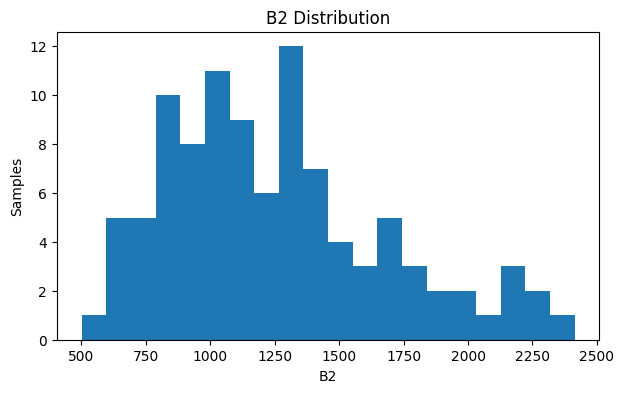

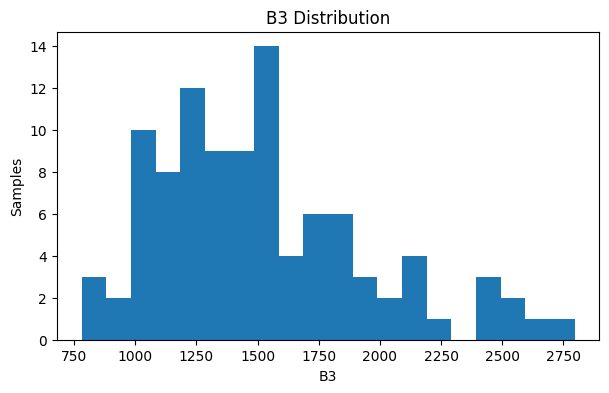

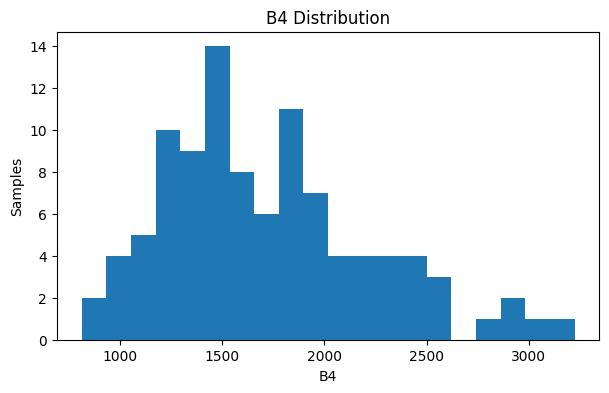

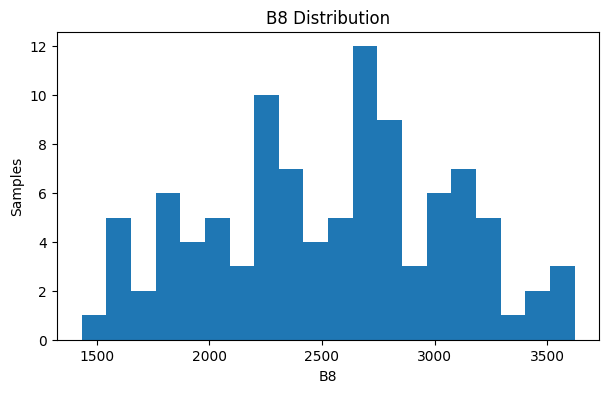

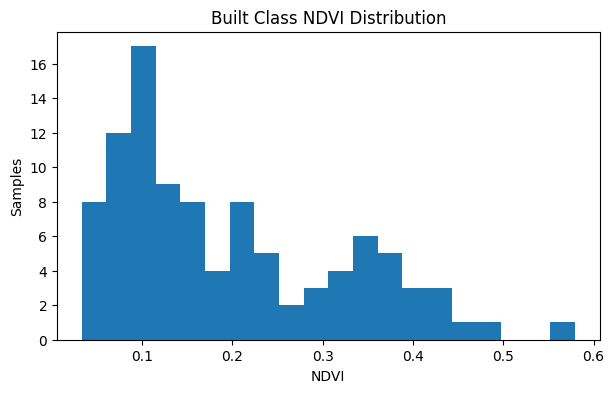

In [22]:
import matplotlib.pyplot as plt

bands = ["B2", "B3", "B4", "B8"]

for band in bands:
    plt.figure(figsize=(7, 4))
    plt.hist(df[band].to_numpy(), bins=20)
    plt.title(f"{band} Distribution")
    plt.xlabel(band)
    plt.ylabel("Samples")
    plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df["NDVI"].to_numpy(), bins=20)
plt.title("Built Class NDVI Distribution")
plt.xlabel("NDVI")
plt.ylabel("Samples")
plt.show()

In [23]:
# Analyze built samples

print("NDVI range:", df["NDVI"].min(), "to", df["NDVI"].max())

print("\nNDVI quantiles:")

for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f"{q:.0%}:", df["NDVI"].quantile(q))

print("\nHigh-NDVI samples (> 0.40):")

high_ndvi = (
    df.filter(pl.col("NDVI") > 0.40)
    .sort("NDVI", descending=True)
)

print(high_ndvi)

print("\nGeographic coverage:")

print(
    "Longitude:",
    df["longitude"].min(),
    "to",
    df["longitude"].max()
)

print(
    "Latitude:",
    df["latitude"].min(),
    "to",
    df["latitude"].max()
)

NDVI range: 0.03322884012539185 to 0.5792604085854668

NDVI quantiles:
10%: 0.06537253782472166
25%: 0.0974267968056788
50%: 0.15883622215679774
75%: 0.28046884343977996
90%: 0.36978297161936563

High-NDVI samples (> 0.40):
shape: (9, 11)
┌─────┬───────────┬───────────┬───────┬───┬───────┬──────────┬──────────┬───────────┐
│ id  ┆ longitude ┆ latitude  ┆ B2    ┆ … ┆ class ┆ NDVI     ┆ GNDVI    ┆ NGRDI     │
│ --- ┆ ---       ┆ ---       ┆ ---   ┆   ┆ ---   ┆ ---      ┆ ---      ┆ ---       │
│ i64 ┆ f64       ┆ f64       ┆ f64   ┆   ┆ str   ┆ f64      ┆ f64      ┆ f64       │
╞═════╪═══════════╪═══════════╪═══════╪═══╪═══════╪══════════╪══════════╪═══════════╡
│ 55  ┆ 72.497322 ┆ 23.137952 ┆ 501.0 ┆ … ┆ built ┆ 0.57926  ┆ 0.592729 ┆ -0.020511 │
│ 10  ┆ 72.517355 ┆ 23.020722 ┆ 750.5 ┆ … ┆ built ┆ 0.480366 ┆ 0.475265 ┆ 0.00661   │
│ 79  ┆ 72.515109 ┆ 23.137682 ┆ 772.0 ┆ … ┆ built ┆ 0.450524 ┆ 0.519142 ┆ -0.089566 │
│ 49  ┆ 72.516995 ┆ 23.044078 ┆ 810.0 ┆ … ┆ built ┆ 0.429454 ┆ 0.433514 ┆

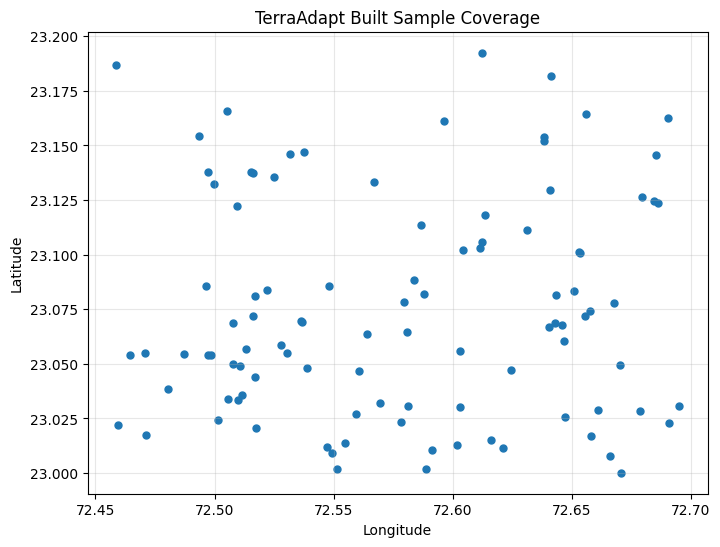

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"].to_numpy(),
    df["latitude"].to_numpy(),
    s=25
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("TerraAdapt Built Sample Coverage")
plt.grid(alpha=0.3)
plt.show()

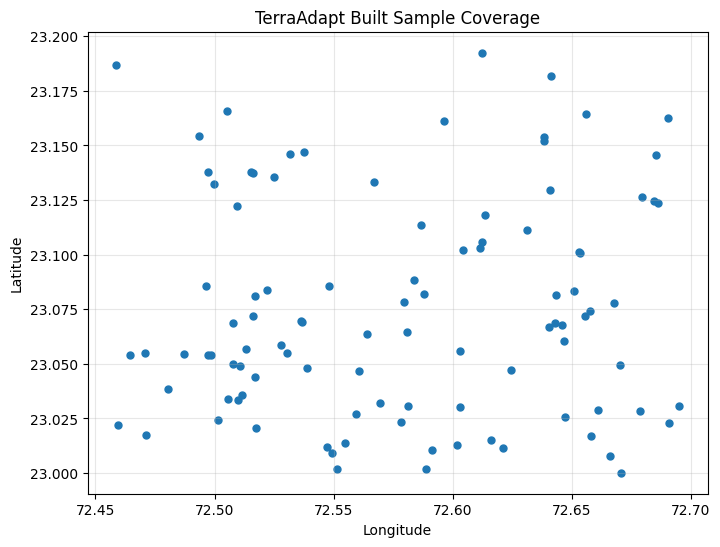

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"].to_numpy(),
    df["latitude"].to_numpy(),
    s=25
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("TerraAdapt Built Sample Coverage")
plt.grid(alpha=0.3)
plt.show()

In [26]:
# Save the 100-point sample dataset

sample_dataset = df.select([
    "id",
    "longitude",
    "latitude",
    "B2",
    "B3",
    "B4",
    "B8",
    "NDVI",
    "GNDVI",
    "NGRDI",
    "class"
])

sample_dataset.write_csv("terraadapt_built_100.csv")
sample_dataset.write_parquet("terraadapt_built_100.parquet")

print("Saved:")
print("terraadapt_built_100.csv")
print("terraadapt_built_100.parquet")
print("Rows:", sample_dataset.height)

Saved:
terraadapt_built_100.csv
terraadapt_built_100.parquet
Rows: 100


In [27]:
# Sample 1,000 high-confidence points per class

samples_per_class = 1000

all_samples = []

for class_id in range(9):
    class_name = classes[class_id]

    points = (
        high_confidence
        .select("label")
        .eq(class_id)
        .selfMask()
        .stratifiedSample(
            numPoints=samples_per_class,
            classBand="label",
            region=region,
            scale=10,
            seed=42 + class_id,
            geometries=True
        )
        .map(
            lambda f: f.set({
                "class_id": class_id,
                "class_name": class_name
            })
        )
    )

    all_samples.append(points)

    print(
        class_id,
        class_name,
        points.size().getInfo()
    )

all_samples_fc = ee.FeatureCollection(all_samples).flatten()

print("\nTotal candidates:", all_samples_fc.size().getInfo())

0 water 1000
1 trees 1000
2 grass 0
3 flooded_vegetation 0
4 crops 68
5 shrub_and_scrub 0
6 built 1000
7 bare 0
8 snow_and_ice 0

Total candidates: 3068


In [28]:
# Convert candidate points to a Polars dataset

candidate_info = all_samples_fc.getInfo()

rows = []

for i, feature in enumerate(candidate_info["features"]):
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    rows.append({
        "id": i,
        "longitude": coords[0],
        "latitude": coords[1],
        "class_id": props.get("class_id"),
        "class": props.get("class_name")
    })

candidate_df = pl.DataFrame(rows)

print("Shape:", candidate_df.shape)
print(candidate_df.group_by("class").len().sort("class"))

Shape: (3068, 5)
shape: (4, 2)
┌───────┬──────┐
│ class ┆ len  │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ built ┆ 1000 │
│ crops ┆ 68   │
│ trees ┆ 1000 │
│ water ┆ 1000 │
└───────┴──────┘


In [29]:
candidate_df.write_parquet("terraadapt_candidates_3068.parquet")
candidate_df.write_csv("terraadapt_candidates_3068.csv")

print("Saved TerraAdapt candidate dataset.")

Saved TerraAdapt candidate dataset.


In [30]:
# Sample Sentinel-2 bands at all candidate points

sentinel_candidates = s2.sampleRegions(
    collection=all_samples_fc,
    scale=10,
    geometries=True
)

print("Sentinel-2 samples:", sentinel_candidates.size().getInfo())

Sentinel-2 samples: 3068


In [31]:
# Convert Sentinel-2 samples to Polars

sample_info = sentinel_candidates.getInfo()

rows = []

for i, feature in enumerate(sample_info["features"]):
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    rows.append({
        "id": i,
        "longitude": coords[0],
        "latitude": coords[1],
        "class_id": props.get("class_id"),
        "class": props.get("class_name"),
        "B2": props.get("B2"),
        "B3": props.get("B3"),
        "B4": props.get("B4"),
        "B8": props.get("B8")
    })

terra_df = pl.DataFrame(rows)

print("Shape:", terra_df.shape)
print("\nClass distribution:")
print(terra_df.group_by(["class_id", "class"]).len().sort("class_id"))

Shape: (3068, 9)

Class distribution:
shape: (4, 3)
┌──────────┬───────┬──────┐
│ class_id ┆ class ┆ len  │
│ ---      ┆ ---   ┆ ---  │
│ i64      ┆ str   ┆ u32  │
╞══════════╪═══════╪══════╡
│ 0        ┆ water ┆ 1000 │
│ 1        ┆ trees ┆ 1000 │
│ 4        ┆ crops ┆ 68   │
│ 6        ┆ built ┆ 1000 │
└──────────┴───────┴──────┘


In [32]:
# Save the final TerraAdapt dataset

terra_df.write_csv("terraadapt_final_3068.csv")
terra_df.write_parquet("terraadapt_final_3068.parquet")

print("Saved:")
print("terraadapt_final_3068.csv")
print("terraadapt_final_3068.parquet")

Saved:
terraadapt_final_3068.csv
terraadapt_final_3068.parquet


In [33]:
# Add vegetation indices

terra_df = terra_df.with_columns([
    ((pl.col("B8") - pl.col("B4")) /
     (pl.col("B8") + pl.col("B4"))).alias("NDVI"),

    ((pl.col("B8") - pl.col("B3")) /
     (pl.col("B8") + pl.col("B3"))).alias("GNDVI"),

    ((pl.col("B3") - pl.col("B4")) /
     (pl.col("B3") + pl.col("B4"))).alias("NGRDI")
])

print("Shape:", terra_df.shape)
print(terra_df.describe())

Shape: (3068, 12)
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ statistic ┆ id        ┆ longitude ┆ latitude  ┆ … ┆ B8        ┆ NDVI     ┆ GNDVI     ┆ NGRDI     │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ count     ┆ 3068.0    ┆ 3068.0    ┆ 3068.0    ┆ … ┆ 3068.0    ┆ 3068.0   ┆ 3068.0    ┆ 3068.0    │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0       ┆ 0.0       │
│ t         ┆           ┆           ┆           ┆   ┆           ┆          ┆           ┆           │
│ mean      ┆ 1533.5    ┆ 72.590504 ┆ 23.101734 ┆ … ┆ 1856.2494 ┆ 0.248753 ┆ 0.204013  ┆ 0.051881  │
│           ┆           ┆           ┆           ┆   ┆ 53  

In [34]:
# Check for suspicious spectral samples

quality_check = terra_df.filter(
    (pl.col("B2") < 0) |
    (pl.col("B3") < 0) |
    (pl.col("B4") < 0) |
    (pl.col("B8") < 0) |
    (pl.col("NDVI") < -1) |
    (pl.col("NDVI") > 1) |
    (pl.col("GNDVI") < -1) |
    (pl.col("GNDVI") > 1) |
    (pl.col("NGRDI") < -1) |
    (pl.col("NGRDI") > 1)
)

print("Suspicious rows:", quality_check.height)

if quality_check.height > 0:
    print(quality_check)

Suspicious rows: 0


In [35]:
# Check geographic coverage by class

geo_stats = (
    terra_df
    .group_by("class")
    .agg([
        pl.len().alias("samples"),
        pl.col("longitude").min().alias("lon_min"),
        pl.col("longitude").max().alias("lon_max"),
        pl.col("latitude").min().alias("lat_min"),
        pl.col("latitude").max().alias("lat_max")
    ])
    .sort("class")
)

print(geo_stats)

shape: (4, 6)
┌───────┬─────────┬───────────┬───────────┬───────────┬───────────┐
│ class ┆ samples ┆ lon_min   ┆ lon_max   ┆ lat_min   ┆ lat_max   │
│ ---   ┆ ---     ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str   ┆ u32     ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪═════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ built ┆ 1000    ┆ 72.4507   ┆ 72.696389 ┆ 23.00033  ┆ 23.199846 │
│ crops ┆ 68      ┆ 72.450071 ┆ 72.696658 ┆ 23.004013 ┆ 23.197151 │
│ trees ┆ 1000    ┆ 72.449981 ┆ 72.689023 ┆ 23.000779 ┆ 23.200025 │
│ water ┆ 1000    ┆ 72.47172  ┆ 72.698994 ┆ 23.00006  ┆ 23.199846 │
└───────┴─────────┴───────────┴───────────┴───────────┴───────────┘


In [36]:
# Create TerraAdapt target labels

terra_df = terra_df.with_columns(
    pl.col("class_id")
    .replace({
        0: 0,
        1: 1,
        4: 2,
        6: 3
    })
    .alias("target_id")
)

terra_df = terra_df.with_columns(
    pl.col("target_id")
    .replace_strict({
        0: "water",
        1: "trees",
        2: "crops",
        3: "built"
    })
    .alias("target_class")
)

print(
    terra_df.select([
        "class_id",
        "class",
        "target_id",
        "target_class"
    ]).unique().sort("target_id")
)

shape: (4, 4)
┌──────────┬───────┬───────────┬──────────────┐
│ class_id ┆ class ┆ target_id ┆ target_class │
│ ---      ┆ ---   ┆ ---       ┆ ---          │
│ i64      ┆ str   ┆ i64       ┆ str          │
╞══════════╪═══════╪═══════════╪══════════════╡
│ 0        ┆ water ┆ 0         ┆ water        │
│ 1        ┆ trees ┆ 1         ┆ trees        │
│ 4        ┆ crops ┆ 2         ┆ crops        │
│ 6        ┆ built ┆ 3         ┆ built        │
└──────────┴───────┴───────────┴──────────────┘


In [37]:
# Save labeled dataset

terra_df.write_parquet("terraadapt_final_labeled.parquet")
terra_df.write_csv("terraadapt_final_labeled.csv")

print("Saved TerraAdapt labeled dataset.")

Saved TerraAdapt labeled dataset.


In [38]:
# Rebuild Dynamic World composite

dw = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .filterBounds(region)
    .filterDate("2024-01-01", "2025-01-01")
)

dw_mean = dw.select([
    "water",
    "trees",
    "grass",
    "flooded_vegetation",
    "crops",
    "shrub_and_scrub",
    "built",
    "bare",
    "snow_and_ice"
]).mean()

print("Dynamic World composite rebuilt.")

Dynamic World composite rebuilt.


In [39]:
# Collect more crop candidates

crop_class_id = 4
crop_confidence = 0.60
crop_samples_needed = 1000

crop_mask = (
    dw_mean.select("crops").gte(crop_confidence)
)

crop_points = (
    crop_mask
    .selfMask()
    .stratifiedSample(
        numPoints=crop_samples_needed,
        region=region,
        scale=10,
        seed=100,
        geometries=True
    )
    .map(
        lambda f: f.set({
            "class_id": crop_class_id,
            "class_name": "crops"
        })
    )
)

print("Crop candidates:", crop_points.size().getInfo())

Crop candidates: 1000


In [40]:
import pandas as pd
import numpy as np
import polars as pl

# Convert Earth Engine crop candidates to coordinates
crop_fc = crop_points.map(
    lambda f: f.set({
        "longitude": f.geometry().coordinates().get(0),
        "latitude": f.geometry().coordinates().get(1)
    })
)

crop_data = crop_fc.getInfo()["features"]

crop_rows = []

for feature in crop_data:
    props = feature["properties"]

    crop_rows.append({
        "longitude": props["longitude"],
        "latitude": props["latitude"],
        "class_id": 4,
        "class": "crops"
    })

crop_df = pl.DataFrame(crop_rows)

print("New crop candidates:", crop_df.height)

# Existing candidate coordinates
existing_coords = terra_df.select([
    "longitude",
    "latitude"
])

# Remove exact coordinate duplicates
crop_df = crop_df.unique(
    subset=["longitude", "latitude"]
)

# Remove crops that already exist in terra_df
crop_df = crop_df.join(
    existing_coords,
    on=["longitude", "latitude"],
    how="anti"
)

print("New unique crop candidates:", crop_df.height)

# Add IDs
max_id = terra_df.select(
    pl.col("id").max()
).item()

crop_df = crop_df.with_columns(
    pl.arange(
        max_id + 1,
        max_id + 1 + crop_df.height
    ).alias("id")
)

# Match terra_df column structure where possible
crop_df = crop_df.select([
    "id",
    "longitude",
    "latitude",
    "class_id",
    "class"
])

print(crop_df.head())

New crop candidates: 1000
New unique crop candidates: 989
shape: (5, 5)
┌──────┬───────────┬───────────┬──────────┬───────┐
│ id   ┆ longitude ┆ latitude  ┆ class_id ┆ class │
│ ---  ┆ ---       ┆ ---       ┆ ---      ┆ ---   │
│ i64  ┆ f64       ┆ f64       ┆ i64      ┆ str   │
╞══════╪═══════════╪═══════════╪══════════╪═══════╡
│ 3068 ┆ 72.686238 ┆ 23.062853 ┆ 4        ┆ crops │
│ 3069 ┆ 72.53029  ┆ 23.150079 ┆ 4        ┆ crops │
│ 3070 ┆ 72.525619 ┆ 23.125914 ┆ 4        ┆ crops │
│ 3071 ┆ 72.684891 ┆ 23.062583 ┆ 4        ┆ crops │
│ 3072 ┆ 72.66899  ┆ 23.135796 ┆ 4        ┆ crops │
└──────┴───────────┴───────────┴──────────┴───────┘


In [41]:
print("Original dataset:", terra_df.height)
print("Additional crops:", crop_df.height)

print("\nOriginal distribution:")
print(
    terra_df
    .group_by("class")
    .len()
    .sort("class")
)

print("\nNew crop distribution:")
print(
    crop_df
    .group_by("class")
    .len()
)

Original dataset: 3068
Additional crops: 989

Original distribution:
shape: (4, 2)
┌───────┬──────┐
│ class ┆ len  │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ built ┆ 1000 │
│ crops ┆ 68   │
│ trees ┆ 1000 │
│ water ┆ 1000 │
└───────┴──────┘

New crop distribution:
shape: (1, 2)
┌───────┬─────┐
│ class ┆ len │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ crops ┆ 989 │
└───────┴─────┘


In [42]:
# Combine original + new crop candidates
terra_candidates = pl.concat(
    [
        terra_df.select([
            "id",
            "longitude",
            "latitude",
            "class_id",
            "class"
        ]),
        crop_df.select([
            "id",
            "longitude",
            "latitude",
            "class_id",
            "class"
        ])
    ],
    how="vertical"
).unique(
    subset=["longitude", "latitude"]
).sort("id")

print("Final candidate count:", terra_candidates.height)

print("\nClass distribution:")
print(
    terra_candidates
    .group_by("class")
    .len()
    .sort("class")
)

# Save checkpoint
terra_candidates.write_csv(
    "terraadapt_candidates_4057.csv"
)

terra_candidates.write_parquet(
    "terraadapt_candidates_4057.parquet"
)

print("\nSaved:")
print("terraadapt_candidates_4057.csv")
print("terraadapt_candidates_4057.parquet")

Final candidate count: 4057

Class distribution:
shape: (4, 2)
┌───────┬──────┐
│ class ┆ len  │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ built ┆ 1000 │
│ crops ┆ 1057 │
│ trees ┆ 1000 │
│ water ┆ 1000 │
└───────┴──────┘

Saved:
terraadapt_candidates_4057.csv
terraadapt_candidates_4057.parquet


In [43]:
print("TerraAdapt candidates:", terra_candidates.height)

print("\nClass distribution:")
print(
    terra_candidates
    .group_by("class")
    .len()
    .sort("class")
)

print("\nColumns:")
print(terra_candidates.columns)

print("\nSample:")
print(terra_candidates.head(5))

TerraAdapt candidates: 4057

Class distribution:
shape: (4, 2)
┌───────┬──────┐
│ class ┆ len  │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ built ┆ 1000 │
│ crops ┆ 1057 │
│ trees ┆ 1000 │
│ water ┆ 1000 │
└───────┴──────┘

Columns:
['id', 'longitude', 'latitude', 'class_id', 'class']

Sample:
shape: (5, 5)
┌─────┬───────────┬───────────┬──────────┬───────┐
│ id  ┆ longitude ┆ latitude  ┆ class_id ┆ class │
│ --- ┆ ---       ┆ ---       ┆ ---      ┆ ---   │
│ i64 ┆ f64       ┆ f64       ┆ i64      ┆ str   │
╞═════╪═══════════╪═══════════╪══════════╪═══════╡
│ 0   ┆ 72.576015 ┆ 23.013625 ┆ 0        ┆ water │
│ 1   ┆ 72.566672 ┆ 23.160859 ┆ 0        ┆ water │
│ 2   ┆ 72.591466 ┆ 23.062763 ┆ 0        ┆ water │
│ 3   ┆ 72.590567 ┆ 23.063392 ┆ 0        ┆ water │
│ 4   ┆ 72.569457 ┆ 23.001228 ┆ 0        ┆ water │
└─────┴───────────┴───────────┴──────────┴───────┘


In [44]:
import ee

ee.Authenticate()

In [45]:
ee.Initialize(project="terraadapt")

In [46]:
ee.Initialize(project="terraadapt")

In [47]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [48]:
features = []

for row in terra_candidates.iter_rows(named=True):
    features.append(
        ee.Feature(
            ee.Geometry.Point([
                row["longitude"],
                row["latitude"]
            ]),
            {
                "id": int(row["id"]),
                "class_id": int(row["class_id"]),
                "class": row["class"]
            }
        )
    )

candidate_fc = ee.FeatureCollection(features)

print("Earth Engine candidate points:", candidate_fc.size().getInfo())

Earth Engine candidate points: 4057


In [49]:
PATCH_SIZE = 224
SCALE = 10

# Sentinel-2 RGB composite
s2_rgb = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2024-01-01", "2025-01-01")
    .filterBounds(region)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .median()
    .select(["B4", "B3", "B2"])
)

# Convert reflectance to float
s2_rgb = s2_rgb.toFloat()

# Create a 224 × 224 pixel projection at 10 m
projection = s2_rgb.select("B4").projection().atScale(SCALE)

print("RGB composite ready")
print("Bands:", s2_rgb.bandNames().getInfo())
print("Patch size:", f"{PATCH_SIZE} × {PATCH_SIZE}")
print("Resolution:", f"{SCALE} m")

RGB composite ready
Bands: ['B4', 'B3', 'B2']
Patch size: 224 × 224
Resolution: 10 m


In [50]:
import math

PATCH_KM = 2.24
HALF_PATCH_METERS = (PATCH_SIZE * SCALE) / 2

# Add a patch geometry around every candidate point
def add_patch_geometry(feature):
    return feature.setGeometry(
        feature.geometry().buffer(HALF_PATCH_METERS).bounds()
    )

patch_fc = candidate_fc.map(add_patch_geometry)

print("Patch features:", patch_fc.size().getInfo())

Patch features: 4057


In [51]:
# Export candidate metadata separately
metadata_task = ee.batch.Export.table.toDrive(
    collection=candidate_fc,
    description="TerraAdapt_candidate_metadata",
    folder="TerraAdapt",
    fileNamePrefix="terraadapt_candidates_4057",
    fileFormat="CSV"
)

metadata_task.start()

print("Metadata export started.")
print("Check Google Drive → TerraAdapt")

Metadata export started.
Check Google Drive → TerraAdapt


In [52]:
# Create 224 × 224 RGB patches centered on candidate points

PATCH_SIZE = 224
SCALE = 10
PATCH_RADIUS = (PATCH_SIZE * SCALE) / 2

def create_patch(feature):
    point = feature.geometry()

    # 224 × 224 pixel footprint at 10 m resolution
    patch_region = point.buffer(PATCH_RADIUS).bounds()

    # Sample the RGB image over the patch
    patch = s2_rgb.sampleRectangle(
        region=patch_region,
        defaultValue=0
    )

    return feature.set({
        "B4_patch": patch.get("B4"),
        "B3_patch": patch.get("B3"),
        "B2_patch": patch.get("B2")
    })

print("Creating patch collection...")

patch_collection = candidate_fc.map(create_patch)

print("Patch collection created.")
print("Number of patches:", patch_collection.size().getInfo())

Creating patch collection...
Patch collection created.
Number of patches: 4057


In [53]:
# Export TerraAdapt patches as TFRecord

export_task = ee.batch.Export.table.toDrive(
    collection=patch_collection,
    description="TerraAdapt_RGB_Patches_4057",
    folder="TerraAdapt",
    fileNamePrefix="terraadapt_rgb_patches_4057",
    fileFormat="TFRecord"
)

export_task.start()

print("Patch export started.")
print("Task ID:", export_task.id)
print("Destination: Google Drive / TerraAdapt")

Patch export started.
Task ID: 2W7DUFA7ZQGGUBSAB2CLG3WK
Destination: Google Drive / TerraAdapt


In [54]:
print(export_task.status())

{'state': 'READY', 'description': 'TerraAdapt_RGB_Patches_4057', 'priority': 100, 'creation_timestamp_ms': 1789020182999, 'update_timestamp_ms': 1789020182999, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': '2W7DUFA7ZQGGUBSAB2CLG3WK', 'name': 'projects/terraadapt/operations/2W7DUFA7ZQGGUBSAB2CLG3WK'}


In [55]:
print(export_task.status())

{'state': 'READY', 'description': 'TerraAdapt_RGB_Patches_4057', 'priority': 100, 'creation_timestamp_ms': 1789020182999, 'update_timestamp_ms': 1789020182999, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': '2W7DUFA7ZQGGUBSAB2CLG3WK', 'name': 'projects/terraadapt/operations/2W7DUFA7ZQGGUBSAB2CLG3WK'}


In [58]:
print(export_task.status())

{'state': 'RUNNING', 'description': 'TerraAdapt_RGB_Patches_4057', 'priority': 100, 'creation_timestamp_ms': 1789020182999, 'update_timestamp_ms': 1789020234867, 'start_timestamp_ms': 1789020194523, 'task_type': 'EXPORT_FEATURES', 'attempt': 1, 'batch_eecu_usage_seconds': 84.040740966, 'id': '2W7DUFA7ZQGGUBSAB2CLG3WK', 'name': 'projects/terraadapt/operations/2W7DUFA7ZQGGUBSAB2CLG3WK'}


In [65]:
print(export_task.status())

{'state': 'CANCELLED', 'description': 'TerraAdapt_RGB_Patches_4057', 'priority': 100, 'creation_timestamp_ms': 1789020182999, 'update_timestamp_ms': 1789020824897, 'start_timestamp_ms': 1789020194523, 'task_type': 'EXPORT_FEATURES', 'attempt': 1, 'batch_eecu_usage_seconds': 726.444763183, 'error_message': 'Cancelled.', 'id': '2W7DUFA7ZQGGUBSAB2CLG3WK', 'name': 'projects/terraadapt/operations/2W7DUFA7ZQGGUBSAB2CLG3WK'}


In [60]:
# Cancel the incorrect TFRecord export
ee.data.cancelTask(export_task.id)

print("Old patch export cancelled.")

Old patch export cancelled.


In [66]:
# Check geographic spread of TerraAdapt points

print("Number of points:", terra_candidates.height)

print("Latitude range:",
      terra_candidates["latitude"].min(),
      "to",
      terra_candidates["latitude"].max())

print("Longitude range:",
      terra_candidates["longitude"].min(),
      "to",
      terra_candidates["longitude"].max())

Number of points: 4057
Latitude range: 23.000060292718373 to 23.20002527496338
Longitude range: 72.44998106375932 to 72.69899406051725


In [73]:
import requests
import math

min_lon = terra_candidates["longitude"].min()
max_lon = terra_candidates["longitude"].max()
min_lat = terra_candidates["latitude"].min()
max_lat = terra_candidates["latitude"].max()

mid_lon = (min_lon + max_lon) / 2
mid_lat = (min_lat + max_lat) / 2

boxes = [
    [min_lon, mid_lat, mid_lon, max_lat],
    [mid_lon, mid_lat, max_lon, max_lat],
    [min_lon, min_lat, mid_lon, mid_lat],
    [mid_lon, min_lat, max_lon, mid_lat],
]

for i, box in enumerate(boxes):
    print(f"Downloading tile {i+1}/4...")

    region = ee.Geometry.Rectangle(box)

    url = s2_rgb.getDownloadURL({
        "region": region,
        "scale": 10,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF"
    })

    response = requests.get(url)

    print(
        "Status:", response.status_code,
        "| Size:",
        round(len(response.content) / 1024 / 1024, 2),
        "MB"
    )

    with open(f"/content/terraadapt_rgb_tile_{i+1}.tif", "wb") as f:
        f.write(response.content)

print("🔥 All 4 RGB tiles downloaded to Colab.")

Status: 200 | Size: 9.92 MB
Status: 200 | Size: 9.2 MB
Status: 200 | Size: 9.91 MB
Status: 200 | Size: 9.51 MB
🔥 All 4 RGB tiles downloaded to Colab.


In [74]:
import os
import numpy as np
import rasterio
from PIL import Image

PATCH_SIZE = 224
OUTPUT_DIR = "/content/TerraAdapt_RGB"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all four tiles
tiles = []

for i in range(1, 5):
    path = f"/content/terraadapt_rgb_tile_{i}.tif"
    src = rasterio.open(path)
    tiles.append(src)
    print(f"Loaded tile {i}: {src.width} x {src.height}")

print("All tiles loaded.")

Loaded tile 1: 1387 x 1114
Loaded tile 2: 1387 x 1114
Loaded tile 3: 1387 x 1114
Loaded tile 4: 1387 x 1114
All tiles loaded.


In [75]:
import os
import numpy as np
from PIL import Image
import rasterio

PATCH_SIZE = 224
HALF = PATCH_SIZE // 2
OUTPUT_DIR = "/content/TerraAdapt_RGB"

os.makedirs(OUTPUT_DIR, exist_ok=True)

count = 0
failed = 0

for row in terra_candidates.iter_rows(named=True):

    lon = row["longitude"]
    lat = row["latitude"]

    found = False

    for src in tiles:

        # Convert geographic coordinate to pixel
        px, py = src.index(lon, lat)

        # Check whether point is inside this tile
        if 0 <= px < src.height and 0 <= py < src.width:

            x = py
            y = px

            # Make sure the full 224x224 patch fits
            if (
                x - HALF >= 0 and
                y - HALF >= 0 and
                x + HALF <= src.width and
                y + HALF <= src.height
            ):

                patch = src.read(
                    window=rasterio.windows.Window(
                        x - HALF,
                        y - HALF,
                        PATCH_SIZE,
                        PATCH_SIZE
                    )
                )

                # Convert bands × height × width → height × width × bands
                patch = np.transpose(patch, (1, 2, 0))

                # Normalize reflectance if necessary
                if patch.max() > 255:
                    patch = np.clip(patch / 10000.0 * 255, 0, 255)

                patch = patch.astype(np.uint8)

                filename = (
                    f"{int(row['id'])}_"
                    f"{row['class']}.png"
                )

                Image.fromarray(patch).save(
                    os.path.join(OUTPUT_DIR, filename)
                )

                count += 1
                found = True
                break

    if not found:
        failed += 1

print(f"✅ Patches created: {count}")
print(f"⚠️ Failed: {failed}")
print(f"📁 Location: {OUTPUT_DIR}")

✅ Patches created: 2610
⚠️ Failed: 1447
📁 Location: /content/TerraAdapt_RGB


In [76]:
from rasterio.merge import merge
import rasterio
import os

# Stitch the 4 tiles into one raster
mosaic, transform = merge(tiles)

print("Mosaic shape:", mosaic.shape)
print("Mosaic size:", mosaic.shape[2], "x", mosaic.shape[1])

# Save the stitched RGB raster
mosaic_path = "/content/terraadapt_rgb_mosaic.tif"

profile = tiles[0].profile.copy()
profile.update(
    height=mosaic.shape[1],
    width=mosaic.shape[2],
    transform=transform
)

with rasterio.open(mosaic_path, "w", **profile) as dst:
    dst.write(mosaic)

print("✅ Mosaic created:", mosaic_path)

Mosaic shape: (3, 2227, 2773)
Mosaic size: 2773 x 2227
✅ Mosaic created: /content/terraadapt_rgb_mosaic.tif


In [77]:
import os
import numpy as np
from PIL import Image
import rasterio
from rasterio.windows import Window

PATCH_SIZE = 224
HALF = PATCH_SIZE // 2
OUTPUT_DIR = "/content/TerraAdapt_RGB"

src = rasterio.open("/content/terraadapt_rgb_mosaic.tif")

count = 0
failed = 0

for row in terra_candidates.iter_rows(named=True):

    lon = row["longitude"]
    lat = row["latitude"]

    px, py = src.index(lon, lat)

    x = py
    y = px

    # Keep only patches that fit inside the complete mosaic
    if (
        x - HALF < 0 or
        y - HALF < 0 or
        x + HALF > src.width or
        y + HALF > src.height
    ):
        failed += 1
        continue

    patch = src.read(
        window=Window(
            x - HALF,
            y - HALF,
            PATCH_SIZE,
            PATCH_SIZE
        )
    )

    patch = np.transpose(patch, (1, 2, 0))

    if patch.max() > 255:
        patch = np.clip(patch / 10000.0 * 255, 0, 255)

    patch = patch.astype(np.uint8)

    filename = f"{int(row['id'])}_{row['class']}.png"

    Image.fromarray(patch).save(
        os.path.join(OUTPUT_DIR, filename)
    )

    count += 1

src.close()

print(f"✅ Total patches: {count}")
print(f"⚠️ Failed: {failed}")
print(f"📁 Dataset: {OUTPUT_DIR}")

✅ Total patches: 3338
⚠️ Failed: 719
📁 Dataset: /content/TerraAdapt_RGB


In [78]:
# Download RGB imagery with enough margin for 224x224 patches

margin = 0.012  # ~1.2 km

min_lon = terra_candidates["longitude"].min() - margin
max_lon = terra_candidates["longitude"].max() + margin
min_lat = terra_candidates["latitude"].min() - margin
max_lat = terra_candidates["latitude"].max() + margin

region = ee.Geometry.Rectangle([
    min_lon, min_lat,
    max_lon, max_lat
])

url = s2_rgb.getDownloadURL({
    "region": region,
    "scale": 10,
    "crs": "EPSG:4326",
    "format": "GEO_TIFF"
})

print("Downloading expanded RGB raster...")

response = requests.get(url)

print("Status:", response.status_code)
print("Size:", round(len(response.content) / 1024 / 1024, 2), "MB")

with open("/content/terraadapt_rgb_expanded.tif", "wb") as f:
    f.write(response.content)

print("✅ Expanded RGB raster downloaded.")

EEException: Total request size (113809425 bytes) must be less than or equal to 50331648 bytes.

In [79]:
# Download expanded RGB area as 4 tiles

margin = 0.012

min_lon = terra_candidates["longitude"].min() - margin
max_lon = terra_candidates["longitude"].max() + margin
min_lat = terra_candidates["latitude"].min() - margin
max_lat = terra_candidates["latitude"].max() + margin

mid_lon = (min_lon + max_lon) / 2
mid_lat = (min_lat + max_lat) / 2

boxes = [
    [min_lon, mid_lat, mid_lon, max_lat],
    [mid_lon, mid_lat, max_lon, max_lat],
    [min_lon, min_lat, mid_lon, mid_lat],
    [mid_lon, min_lat, max_lon, mid_lat],
]

for i, box in enumerate(boxes, 1):

    print(f"Downloading tile {i}/4...")

    region = ee.Geometry.Rectangle(box)

    url = s2_rgb.getDownloadURL({
        "region": region,
        "scale": 10,
        "crs": "EPSG:4326",
        "format": "GEO_TIFF"
    })

    response = requests.get(url)

    size_mb = len(response.content) / 1024 / 1024

    print(f"Status: {response.status_code} | Size: {size_mb:.2f} MB")

    with open(f"/content/terraadapt_rgb_expanded_tile_{i}.tif", "wb") as f:
        f.write(response.content)

print("🔥 All expanded tiles downloaded.")

Status: 200 | Size: 12.01 MB
Status: 200 | Size: 11.24 MB
Status: 200 | Size: 12.01 MB
Status: 200 | Size: 11.55 MB
🔥 All expanded tiles downloaded.


In [80]:
import rasterio
from rasterio.merge import merge

expanded_tiles = []

for i in range(1, 5):
    path = f"/content/terraadapt_rgb_expanded_tile_{i}.tif"
    expanded_tiles.append(rasterio.open(path))

mosaic, transform = merge(expanded_tiles)

profile = expanded_tiles[0].profile.copy()
profile.update(
    height=mosaic.shape[1],
    width=mosaic.shape[2],
    transform=transform
)

mosaic_path = "/content/terraadapt_rgb_final_mosaic.tif"

with rasterio.open(mosaic_path, "w", **profile) as dst:
    dst.write(mosaic)

print("✅ Final mosaic created")
print("Shape:", mosaic.shape)
print("Size:", mosaic.shape[2], "x", mosaic.shape[1])

✅ Final mosaic created
Shape: (3, 2495, 3041)
Size: 3041 x 2495


In [81]:
import os
import numpy as np
import rasterio
from PIL import Image
from rasterio.windows import Window

PATCH_SIZE = 224
HALF = PATCH_SIZE // 2
OUTPUT_DIR = "/content/TerraAdapt_RGB_Final"

os.makedirs(OUTPUT_DIR, exist_ok=True)

src = rasterio.open("/content/terraadapt_rgb_final_mosaic.tif")

count = 0
failed = 0

for row in terra_candidates.iter_rows(named=True):

    lon = row["longitude"]
    lat = row["latitude"]

    px, py = src.index(lon, lat)

    x = py
    y = px

    if (
        x - HALF < 0 or
        y - HALF < 0 or
        x + HALF > src.width or
        y + HALF > src.height
    ):
        failed += 1
        continue

    patch = src.read(
        window=Window(
            x - HALF,
            y - HALF,
            PATCH_SIZE,
            PATCH_SIZE
        )
    )

    patch = np.transpose(patch, (1, 2, 0))

    if patch.max() > 255:
        patch = np.clip(patch / 10000.0 * 255, 0, 255)

    patch = patch.astype(np.uint8)

    filename = f"{int(row['id'])}_{row['class']}.png"

    Image.fromarray(patch).save(
        os.path.join(OUTPUT_DIR, filename)
    )

    count += 1

src.close()

print(f"✅ Patches created: {count}")
print(f"⚠️ Failed: {failed}")
print(f"📁 Dataset: {OUTPUT_DIR}")

✅ Patches created: 4057
⚠️ Failed: 0
📁 Dataset: /content/TerraAdapt_RGB_Final


In [82]:
import shutil
import os

dataset_dir = "/content/TerraAdapt_RGB_Final"
zip_path = "/content/TerraAdapt_RGB_4057"

shutil.make_archive(
    zip_path,
    "zip",
    dataset_dir
)

final_file = zip_path + ".zip"

size_gb = os.path.getsize(final_file) / (1024**3)

print(f"✅ ZIP created: {final_file}")
print(f"📦 Size: {size_gb:.2f} GB")

✅ ZIP created: /content/TerraAdapt_RGB_4057.zip
📦 Size: 0.28 GB


In [87]:
import torch
import os

MODEL_PATH = "/resnet50_finetuned_layer4_best.pth"

print("File exists:", os.path.exists(MODEL_PATH))

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for key in checkpoint.keys():
        print(" -", key)

    if "state_dict" in checkpoint:
        print("\nState dict sample keys:")
        print(list(checkpoint["state_dict"].keys())[:10])
    else:
        print("\nCheckpoint sample keys:")
        print(list(checkpoint.keys())[:10])

File exists: True
Checkpoint type: <class 'collections.OrderedDict'>

Checkpoint keys:
 - conv1.weight
 - bn1.weight
 - bn1.bias
 - bn1.running_mean
 - bn1.running_var
 - bn1.num_batches_tracked
 - layer1.0.conv1.weight
 - layer1.0.bn1.weight
 - layer1.0.bn1.bias
 - layer1.0.bn1.running_mean
 - layer1.0.bn1.running_var
 - layer1.0.bn1.num_batches_tracked
 - layer1.0.conv2.weight
 - layer1.0.bn2.weight
 - layer1.0.bn2.bias
 - layer1.0.bn2.running_mean
 - layer1.0.bn2.running_var
 - layer1.0.bn2.num_batches_tracked
 - layer1.0.conv3.weight
 - layer1.0.bn3.weight
 - layer1.0.bn3.bias
 - layer1.0.bn3.running_mean
 - layer1.0.bn3.running_var
 - layer1.0.bn3.num_batches_tracked
 - layer1.0.downsample.0.weight
 - layer1.0.downsample.1.weight
 - layer1.0.downsample.1.bias
 - layer1.0.downsample.1.running_mean
 - layer1.0.downsample.1.running_var
 - layer1.0.downsample.1.num_batches_tracked
 - layer1.1.conv1.weight
 - layer1.1.bn1.weight
 - layer1.1.bn1.bias
 - layer1.1.bn1.running_mean
 - laye

In [89]:
import torch

checkpoint = torch.load(
    "/resnet50_finetuned_layer4_best.pth",
    map_location="cpu"
)

print("Total parameters:", len(checkpoint))

print("\nFinal classifier weights:")
print("Shape:", checkpoint["fc.weight"].shape)

print("\nFinal classifier bias:")
print("Shape:", checkpoint["fc.bias"].shape)

Total parameters: 320

Final classifier weights:
Shape: torch.Size([10, 2048])

Final classifier bias:
Shape: torch.Size([10])


In [90]:
import torch
import torch.nn as nn
from torchvision.models import resnet50

MODEL_PATH = "/resnet50_finetuned_layer4_best.pth"

# Load the original ResNet50 architecture
model = resnet50(weights=None)

# Replace the 10-class EuroSAT classifier with TerraAdapt's 4 classes
model.fc = nn.Linear(2048, 4)

# Load the pretrained checkpoint except the old 10-class FC
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

backbone_weights = {
    key: value
    for key, value in checkpoint.items()
    if not key.startswith("fc.")
}

missing, unexpected = model.load_state_dict(
    backbone_weights,
    strict=False
)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

print("\nTerraAdapt classifier:")
print(model.fc)

print("\nOutput classes:", model.fc.out_features)

Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []

TerraAdapt classifier:
Linear(in_features=2048, out_features=4, bias=True)

Output classes: 4


In [91]:
import os
from PIL import Image
from collections import Counter

DATASET_DIR = "/content/TerraAdapt_RGB_Final"

class_names = {
    0: "water",
    1: "trees",
    2: "crops",
    3: "built"
}

files = [
    f for f in os.listdir(DATASET_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
]

print("Total image files:", len(files))

# Inspect filenames for class labels
class_counts = Counter()

for filename in files:
    name = filename.lower()

    for class_id, class_name in class_names.items():
        if class_name in name:
            class_counts[class_name] += 1
            break

print("\nClass counts:")
for class_name in class_names.values():
    print(f"{class_name}: {class_counts[class_name]}")

# Check image dimensions and corrupted files
bad_images = []
sizes = Counter()

for filename in files:
    path = os.path.join(DATASET_DIR, filename)

    try:
        with Image.open(path) as img:
            sizes[img.size] += 1
    except Exception:
        bad_images.append(filename)

print("\nImage sizes:")
for size, count in sizes.items():
    print(f"{size}: {count}")

print("\nCorrupted images:", len(bad_images))

if bad_images:
    print("Examples:", bad_images[:10])

Total image files: 4057

Class counts:
water: 1000
trees: 1000
crops: 1057
built: 1000

Image sizes:
(224, 224): 4057

Corrupted images: 0


In [92]:
import polars as pl
import os

CSV_PATH = "/content/terraadapt_candidates_4057.csv"

terra_candidates = pl.read_csv(CSV_PATH)

print("Rows:", terra_candidates.height)
print("Columns:")
print(terra_candidates.columns)

print("\nFirst 5 rows:")
print(terra_candidates.head())

Rows: 4057
Columns:
['id', 'longitude', 'latitude', 'class_id', 'class']

First 5 rows:
shape: (5, 5)
┌─────┬───────────┬───────────┬──────────┬───────┐
│ id  ┆ longitude ┆ latitude  ┆ class_id ┆ class │
│ --- ┆ ---       ┆ ---       ┆ ---      ┆ ---   │
│ i64 ┆ f64       ┆ f64       ┆ i64      ┆ str   │
╞═════╪═══════════╪═══════════╪══════════╪═══════╡
│ 0   ┆ 72.576015 ┆ 23.013625 ┆ 0        ┆ water │
│ 1   ┆ 72.566672 ┆ 23.160859 ┆ 0        ┆ water │
│ 2   ┆ 72.591466 ┆ 23.062763 ┆ 0        ┆ water │
│ 3   ┆ 72.590567 ┆ 23.063392 ┆ 0        ┆ water │
│ 4   ┆ 72.569457 ┆ 23.001228 ┆ 0        ┆ water │
└─────┴───────────┴───────────┴──────────┴───────┘


In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

csv_path = "/content/terraadapt_candidates_4057.csv"

df = pd.read_csv(csv_path)

print("Total rows:", len(df))
print("Columns:", df.columns.tolist())
print("\nClass distribution:")
print(df["class"].value_counts())

# Create coarse geographic grid cells.
# Nearby patches fall into the same spatial group.
grid_size = 0.02

df["lon_grid"] = np.floor(df["longitude"] / grid_size)
df["lat_grid"] = np.floor(df["latitude"] / grid_size)

df["spatial_group"] = (
    df["lon_grid"].astype(str) + "_" +
    df["lat_grid"].astype(str)
)

print("\nUnique spatial groups:", df["spatial_group"].nunique())

# Keep complete spatial groups together.
group_info = (
    df.groupby("spatial_group")
      .agg(
          n_samples=("id", "size"),
          n_classes=("class_id", "nunique")
      )
      .reset_index()
)

print("\nSpatial group size summary:")
print(group_info["n_samples"].describe())

# Shuffle spatial groups reproducibly
groups = group_info["spatial_group"].to_numpy()
rng = np.random.default_rng(42)
rng.shuffle(groups)

# Approximately 70 / 15 / 15 split by spatial groups
n_groups = len(groups)

n_train = int(n_groups * 0.70)
n_val = int(n_groups * 0.15)

train_groups = set(groups[:n_train])
val_groups = set(groups[n_train:n_train + n_val])
test_groups = set(groups[n_train + n_val:])

df["split"] = np.where(
    df["spatial_group"].isin(train_groups),
    "train",
    np.where(
        df["spatial_group"].isin(val_groups),
        "val",
        "test"
    )
)

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nClass distribution by split:")
print(
    pd.crosstab(
        df["split"],
        df["class"],
        margins=True
    )
)

# Remove helper columns from saved metadata
split_df = df.drop(
    columns=["lon_grid", "lat_grid", "spatial_group"]
)

split_path = "/content/terraadapt_spatial_split.csv"
split_df.to_csv(split_path, index=False)

print("\nSaved:", split_path)
print("\nFirst rows:")
display(split_df.head())

Total rows: 4057
Columns: ['id', 'longitude', 'latitude', 'class_id', 'class']

Class distribution:
class
crops    1057
water    1000
trees    1000
built    1000
Name: count, dtype: int64

Unique spatial groups: 131

Spatial group size summary:
count    131.000000
mean      30.969466
std       45.805935
min        1.000000
25%       10.000000
50%       16.000000
75%       31.000000
max      378.000000
Name: n_samples, dtype: float64

Split distribution:
split
train    2792
val       692
test      573
Name: count, dtype: int64

Class distribution by split:
class  built  crops  trees  water   All
split                                  
test     162    145    193     73   573
train    688    874    623    607  2792
val      150     38    184    320   692
All     1000   1057   1000   1000  4057

Saved: /content/terraadapt_spatial_split.csv

First rows:


,id,longitude,latitude,class_id,class,split
0,0,72.576015,23.013625,0,water,val
1,1,72.566672,23.160859,0,water,train
2,2,72.591466,23.062763,0,water,train
3,3,72.590567,23.063392,0,water,train
4,4,72.569457,23.001228,0,water,val


In [94]:
# Build a more class-balanced spatial split

from collections import defaultdict

groups = df["spatial_group"].unique()

group_classes = (
    df.groupby("spatial_group")["class"]
    .apply(set)
    .to_dict()
)

class_totals = df["class"].value_counts().to_dict()

targets = {
    "train": 0.70,
    "val": 0.15,
    "test": 0.15
}

split_rows = defaultdict(list)
split_counts = {
    split: defaultdict(int)
    for split in targets
}

rng = np.random.default_rng(42)
rng.shuffle(groups)

# Process larger geographic groups first
groups = sorted(
    groups,
    key=lambda g: len(df[df["spatial_group"] == g]),
    reverse=True
)

for group in groups:
    group_df = df[df["spatial_group"] == group]

    scores = {}

    for split, target_ratio in targets.items():
        score = 0

        for cls, count in group_df["class"].value_counts().items():
            target = class_totals[cls] * target_ratio
            current = split_counts[split][cls]

            score += max(0, current + count - target)

        # Keep the overall split sizes close to target
        target_size = len(df) * target_ratio
        current_size = sum(split_counts[split].values())

        score += max(
            0,
            (current_size + len(group_df) - target_size) / 10
        )

        scores[split] = score

    chosen = min(scores, key=scores.get)

    split_rows[chosen].extend(group_df.index.tolist())

    for cls, count in group_df["class"].value_counts().items():
        split_counts[chosen][cls] += count

df["split"] = "train"
df.loc[split_rows["val"], "split"] = "val"
df.loc[split_rows["test"], "split"] = "test"

split_df = df[
    ["id", "longitude", "latitude", "class_id", "class", "split"]
].copy()

split_path = "/content/terraadapt_spatial_split.csv"
split_df.to_csv(split_path, index=False)

print("Split distribution:")
print(split_df["split"].value_counts())

print("\nClass distribution by split:")
print(pd.crosstab(split_df["split"], split_df["class"]))

print("\nSaved:", split_path)

Split distribution:
split
train    2839
test      609
val       609
Name: count, dtype: int64

Class distribution by split:
class  built  crops  trees  water
split                            
test     150    159    150    150
train    700    739    700    700
val      150    159    150    150

Saved: /content/terraadapt_spatial_split.csv


In [95]:
from pathlib import Path

image_dir = Path("/content/TerraAdapt_RGB_Final")

image_files = {
    p.stem
    for p in image_dir.glob("*.png")
}

split_ids = set(split_df["id"].astype(str))

missing = split_ids - image_files
extra = image_files - split_ids

print("Metadata samples:", len(split_df))
print("Image files:", len(image_files))
print("Missing images:", len(missing))
print("Extra images:", len(extra))

print("\nImages by split:")
print(split_df["split"].value_counts())

if missing:
    print("\nMissing IDs:", list(missing)[:10])
else:
    print("\nAll metadata samples have matching images.")

Metadata samples: 4057
Image files: 4057
Missing images: 4057
Extra images: 4057

Images by split:
split
train    2839
test      609
val       609
Name: count, dtype: int64

Missing IDs: ['171', '2458', '3549', '1612', '104', '2618', '204', '3328', '3689', '3225']


In [98]:
print("First 20 image filenames:")

for p in sorted(image_dir.iterdir())[:20]:
    print(p.name)

print("\nFirst 20 metadata IDs:")
print(split_df["id"].head(20).tolist())

First 20 image filenames:
0_water.png
1000_trees.png
1001_trees.png
1002_trees.png
1003_trees.png
1004_trees.png
1005_trees.png
1006_trees.png
1007_trees.png
1008_trees.png
1009_trees.png
100_water.png
1010_trees.png
1011_trees.png
1012_trees.png
1013_trees.png
1014_trees.png
1015_trees.png
1016_trees.png
1017_trees.png

First 20 metadata IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [99]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TerraAdaptDataset(Dataset):
    def __init__(self, data, image_dir, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

        self.image_map = {
            int(p.stem.split("_")[0]): p
            for p in self.image_dir.glob("*.png")
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_id = int(row["id"])

        image = Image.open(self.image_map[image_id]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(row["class_id"])

        return image, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = split_df[split_df["split"] == "train"]
val_data = split_df[split_df["split"] == "val"]
test_data = split_df[split_df["split"] == "test"]

train_dataset = TerraAdaptDataset(
    train_data, image_dir, train_transform
)

val_dataset = TerraAdaptDataset(
    val_data, image_dir, eval_transform
)

test_dataset = TerraAdaptDataset(
    test_data, image_dir, eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

images, labels = next(iter(train_loader))

print("\nBatch images:", images.shape)
print("Batch labels:", labels.shape)
print("Labels:", labels[:10].tolist())

Train: 2839
Validation: 609
Test: 609

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])
Labels: [1, 0, 0, 1, 1, 6, 0, 1, 4, 4]


In [100]:
class_to_idx = {
    "water": 0,
    "trees": 1,
    "crops": 2,
    "built": 3
}

split_df["target"] = split_df["class"].map(class_to_idx)

print(split_df["target"].value_counts().sort_index())

train_data = split_df[split_df["split"] == "train"]
val_data = split_df[split_df["split"] == "val"]
test_data = split_df[split_df["split"] == "test"]


class TerraAdaptDataset(Dataset):
    def __init__(self, data, image_dir, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

        self.image_map = {
            int(p.stem.split("_")[0]): p
            for p in self.image_dir.glob("*.png")
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_id = int(row["id"])

        image = Image.open(
            self.image_map[image_id]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(row["target"])

        return image, label


train_dataset = TerraAdaptDataset(
    train_data, image_dir, train_transform
)

val_dataset = TerraAdaptDataset(
    val_data, image_dir, eval_transform
)

test_dataset = TerraAdaptDataset(
    test_data, image_dir, eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("\nBatch images:", images.shape)
print("Batch labels:", labels.shape)
print("Labels:", labels[:10].tolist())

target
0    1000
1    1000
2    1057
3    1000
Name: count, dtype: int64

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])
Labels: [1, 1, 1, 0, 0, 1, 3, 2, 0, 3]


In [101]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)

source_state = torch.load(
    "/resnet50_finetuned_layer4_best.pth",
    map_location="cpu"
)

source_state = {
    k: v for k, v in source_state.items()
    if not k.startswith("fc.")
}

model.load_state_dict(source_state, strict=False)

model.fc = nn.Linear(2048, 4)

model = model.to(device)

print("Device:", device)
print("Classifier:", model.fc)
print("Output classes:", model.fc.out_features)

Device: cuda
Classifier: Linear(in_features=2048, out_features=4, bias=True)
Output classes: 4


In [102]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print("\nTrainable layers:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters: 14,972,932
Total parameters: 23,516,228

Trainable layers:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [103]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Layer4 LR:", 1e-5)
print("Classifier LR:", 1e-4)

Loss: CrossEntropyLoss()
Optimizer: AdamW
Layer4 LR: 1e-05
Classifier LR: 0.0001


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

num_epochs = 10
best_val_f1 = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    model.train()

    train_losses = []
    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.extend(outputs.argmax(1).detach().cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = np.mean(train_losses)
    train_f1 = f1_score(
        train_labels,
        train_preds,
        average="macro"
    )

    model.eval()

    val_losses = []
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_losses.append(loss.item())
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_f1 = f1_score(
        val_labels,
        val_preds,
        average="macro"
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            "/content/terraadapt_resnet50_best.pth"
        )

        print(f"  Saved best model | Val F1: {val_f1:.4f}")

print("\nBest validation F1:", f"{best_val_f1:.4f}")

Epoch 01/10 | Train Loss: 1.1183 | Val Loss: 1.1583 | Train F1: 0.6976 | Val F1: 0.4878
  Saved best model | Val F1: 0.4878
Epoch 02/10 | Train Loss: 0.6455 | Val Loss: 1.0089 | Train F1: 0.8436 | Val F1: 0.5504
  Saved best model | Val F1: 0.5504
Epoch 03/10 | Train Loss: 0.4095 | Val Loss: 0.9329 | Train F1: 0.8696 | Val F1: 0.6783
  Saved best model | Val F1: 0.6783
Epoch 04/10 | Train Loss: 0.3312 | Val Loss: 0.9411 | Train F1: 0.8824 | Val F1: 0.7057
  Saved best model | Val F1: 0.7057
Epoch 05/10 | Train Loss: 0.2777 | Val Loss: 0.9323 | Train F1: 0.8972 | Val F1: 0.7035
Epoch 06/10 | Train Loss: 0.2443 | Val Loss: 0.9444 | Train F1: 0.9115 | Val F1: 0.7162
  Saved best model | Val F1: 0.7162
Epoch 07/10 | Train Loss: 0.2199 | Val Loss: 0.9328 | Train F1: 0.9226 | Val F1: 0.7084
Epoch 08/10 | Train Loss: 0.2086 | Val Loss: 0.9860 | Train F1: 0.9272 | Val F1: 0.6699
Epoch 09/10 | Train Loss: 0.1791 | Val Loss: 1.0344 | Train F1: 0.9345 | Val F1: 0.6689
Epoch 10/10 | Train Loss: 0.

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.load_state_dict(
    torch.load(
        "/content/terraadapt_resnet50_best.pth",
        map_location=device
    )
)

model.eval()

val_preds = []
val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        val_probs.extend(probs.cpu().numpy())
        val_preds.extend(outputs.argmax(1).cpu().numpy())
        val_labels.extend(labels.numpy())

val_accuracy = accuracy_score(val_labels, val_preds)
val_precision = precision_score(
    val_labels, val_preds, average="macro"
)
val_recall = recall_score(
    val_labels, val_preds, average="macro"
)
val_f1 = f1_score(
    val_labels, val_preds, average="macro"
)

print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation Macro F1:  {val_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        val_labels,
        val_preds,
        target_names=["water", "trees", "crops", "built"],
        digits=4
    )
)

print("Confusion Matrix:")
print(confusion_matrix(val_labels, val_preds))

Validation Accuracy:  0.7176
Validation Precision: 0.7444
Validation Recall:    0.7191
Validation Macro F1:  0.7179

Classification Report:
              precision    recall  f1-score   support

       water     0.8512    0.6867    0.7601       150
       trees     0.6098    0.6667    0.6369       150
       crops     0.8750    0.6164    0.7232       159
       built     0.6415    0.9067    0.7514       150

    accuracy                         0.7176       609
   macro avg     0.7444    0.7191    0.7179       609
weighted avg     0.7463    0.7176    0.7180       609

Confusion Matrix:
[[103   9   2  36]
 [ 12 100   8  30]
 [  6  45  98  10]
 [  0  10   4 136]]


In [106]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")

Trainable parameters: 22,071,300
Total parameters: 23,516,228


In [107]:
model.load_state_dict(
    torch.load(
        "/content/terraadapt_resnet50_best.pth",
        map_location=device
    )
)

optimizer = optim.AdamW([
    {"params": model.layer3.parameters(), "lr": 5e-6},
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 5e-5}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Optimizer:", optimizer.__class__.__name__)
print("Layer3 LR:", 5e-6)
print("Layer4 LR:", 1e-5)
print("Classifier LR:", 5e-5)

Optimizer: AdamW
Layer3 LR: 5e-06
Layer4 LR: 1e-05
Classifier LR: 5e-05


In [108]:
# Load the best validation checkpoint
model.load_state_dict(
    torch.load(
        "/content/terraadapt_resnet50_best.pth",
        map_location=device
    )
)

# Set optimizer for deeper fine-tuning
optimizer = optim.AdamW([
    {"params": model.layer3.parameters(), "lr": 5e-6},
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 5e-5}
], weight_decay=1e-4)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Optimizer:", optimizer.__class__.__name__)
print("Layer3 LR:", 5e-6)
print("Layer4 LR:", 1e-5)
print("Classifier LR:", 5e-5)

Optimizer: AdamW
Layer3 LR: 5e-06
Layer4 LR: 1e-05
Classifier LR: 5e-05


In [109]:
# Deeper fine-tuning

num_epochs = 8
best_val_f1 = 0.0

for epoch in range(num_epochs):
    model.train()

    train_loss = 0.0
    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        train_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader.dataset)

    train_f1 = f1_score(
        train_labels,
        train_preds,
        average="macro"
    )

    model.eval()

    val_loss = 0.0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average="macro"
    )

    scheduler.step(val_f1)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    # Save the best validation model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            "/content/terraadapt_resnet50_layer3_best.pth"
        )

        print(f"  Best model saved | Val F1: {best_val_f1:.4f}")

print(f"\nBest validation F1: {best_val_f1:.4f}")

Epoch 01/8 | Train Loss: 0.1620 | Val Loss: 1.1043 | Train F1: 0.9374 | Val F1: 0.6900
  Best model saved | Val F1: 0.6900
Epoch 02/8 | Train Loss: 0.1482 | Val Loss: 1.1386 | Train F1: 0.9468 | Val F1: 0.6475
Epoch 03/8 | Train Loss: 0.1400 | Val Loss: 1.1778 | Train F1: 0.9511 | Val F1: 0.6629
Epoch 04/8 | Train Loss: 0.1248 | Val Loss: 1.1527 | Train F1: 0.9557 | Val F1: 0.6667
Epoch 05/8 | Train Loss: 0.1207 | Val Loss: 1.0744 | Train F1: 0.9627 | Val F1: 0.7031
  Best model saved | Val F1: 0.7031
Epoch 06/8 | Train Loss: 0.1139 | Val Loss: 1.2224 | Train F1: 0.9631 | Val F1: 0.6129
Epoch 07/8 | Train Loss: 0.1108 | Val Loss: 1.2269 | Train F1: 0.9638 | Val F1: 0.6314
Epoch 08/8 | Train Loss: 0.0994 | Val Loss: 1.2546 | Train F1: 0.9652 | Val F1: 0.6108

Best validation F1: 0.7031


In [111]:
# Imports for validation analysis

import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Load the best validation checkpoint

model.load_state_dict(
    torch.load(
        "/content/terraadapt_resnet50_best.pth",
        map_location=device
    )
)

model.eval()

val_preds = []
val_labels = []
val_probs = []

# Collect predictions and probabilities

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)
val_probs = np.array(val_probs)

# Calculate overall metrics

accuracy = accuracy_score(val_labels, val_preds)

precision = precision_score(
    val_labels,
    val_preds,
    average="macro"
)

recall = recall_score(
    val_labels,
    val_preds,
    average="macro"
)

f1 = f1_score(
    val_labels,
    val_preds,
    average="macro"
)

roc_auc_macro = roc_auc_score(
    val_labels,
    val_probs,
    multi_class="ovr",
    average="macro"
)

roc_auc_weighted = roc_auc_score(
    val_labels,
    val_probs,
    multi_class="ovr",
    average="weighted"
)

# Display results

print("Validation Metrics")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Macro Precision:   {precision:.4f}")
print(f"Macro Recall:      {recall:.4f}")
print(f"Macro F1:          {f1:.4f}")
print(f"Macro ROC-AUC:     {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC:  {roc_auc_weighted:.4f}")

print("\nClassification Report")

print(
    classification_report(
        val_labels,
        val_preds,
        target_names=[
            "water",
            "trees",
            "crops",
            "built"
        ],
        digits=4
    )
)

Validation Metrics
Accuracy:          0.7176
Macro Precision:   0.7444
Macro Recall:      0.7191
Macro F1:          0.7179
Macro ROC-AUC:     0.8682
Weighted ROC-AUC:  0.8687

Classification Report
              precision    recall  f1-score   support

       water     0.8512    0.6867    0.7601       150
       trees     0.6098    0.6667    0.6369       150
       crops     0.8750    0.6164    0.7232       159
       built     0.6415    0.9067    0.7514       150

    accuracy                         0.7176       609
   macro avg     0.7444    0.7191    0.7179       609
weighted avg     0.7463    0.7176    0.7180       609



Confusion Matrix:
[[103   9   2  36]
 [ 12 100   8  30]
 [  6  45  98  10]
 [  0  10   4 136]]


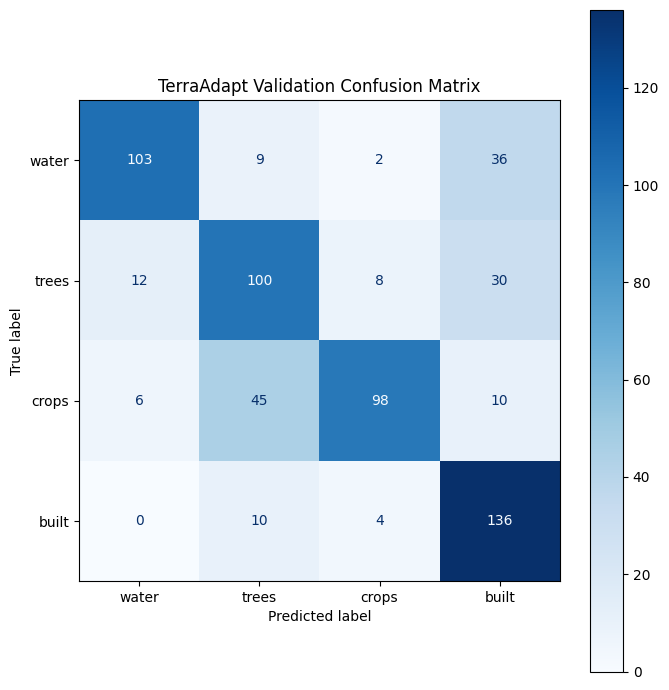

In [112]:
# Confusion matrix analysis

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

cm = confusion_matrix(
    val_labels,
    val_preds
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

ax.set_title("TerraAdapt Validation Confusion Matrix")
plt.tight_layout()
plt.show()

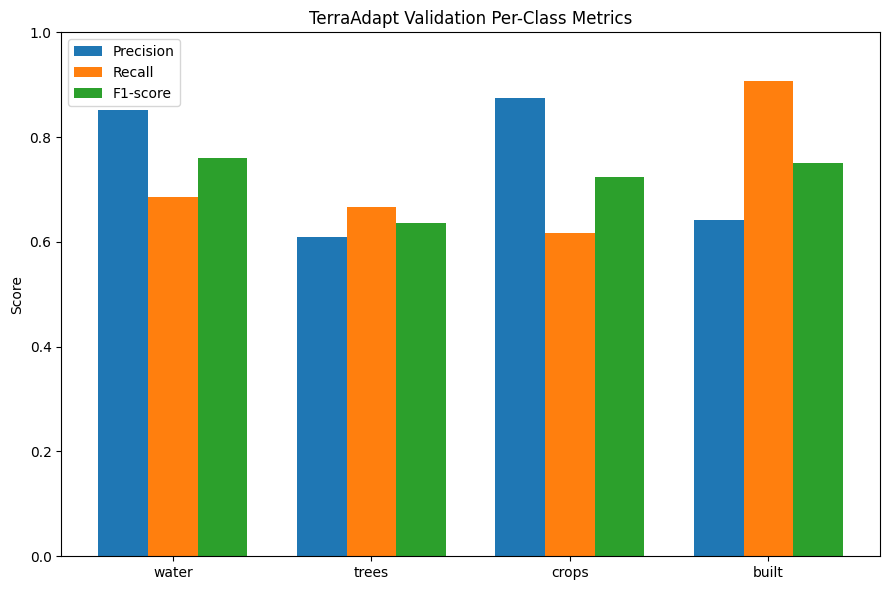

Per-class metrics:
water  | Precision: 0.8512 | Recall: 0.6867 | F1: 0.7601
trees  | Precision: 0.6098 | Recall: 0.6667 | F1: 0.6369
crops  | Precision: 0.8750 | Recall: 0.6164 | F1: 0.7232
built  | Precision: 0.6415 | Recall: 0.9067 | F1: 0.7514


In [113]:
# Per-class performance analysis

from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

precision, recall, f1, support = precision_recall_fscore_support(
    val_labels,
    val_preds,
    labels=[0, 1, 2, 3],
    zero_division=0
)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1-score")

ax.set_title("TerraAdapt Validation Per-Class Metrics")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

print("Per-class metrics:")
for i, name in enumerate(class_names):
    print(
        f"{name:6s} | "
        f"Precision: {precision[i]:.4f} | "
        f"Recall: {recall[i]:.4f} | "
        f"F1: {f1[i]:.4f}"
    )

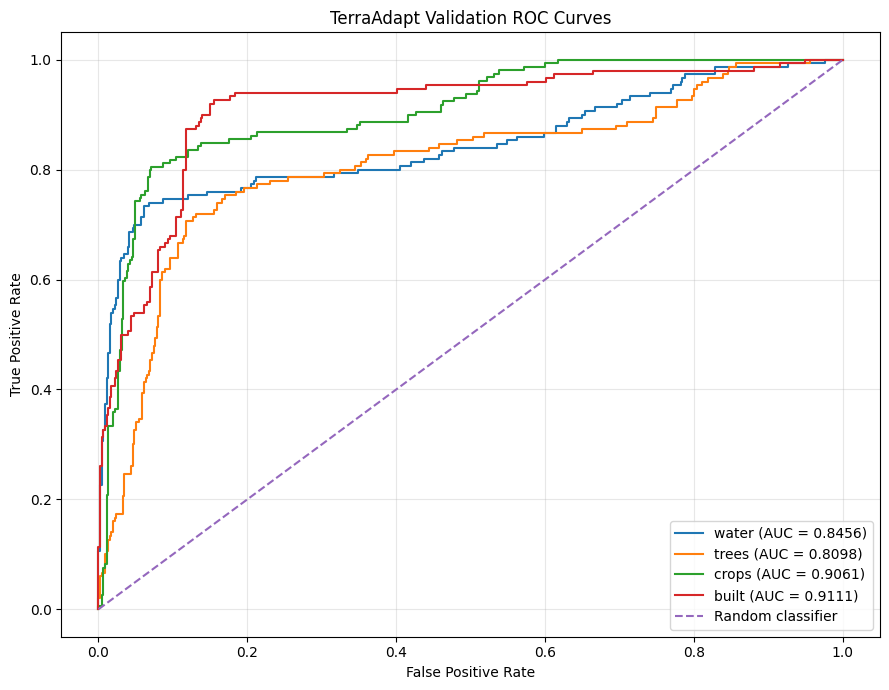

Per-class ROC-AUC:
water : 0.8456
trees : 0.8098
crops : 0.9061
built : 0.9111

Macro ROC-AUC:    0.8682
Weighted ROC-AUC: 0.8687


In [114]:
# ROC-AUC analysis

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

# Convert labels to one-vs-rest format
val_labels_bin = label_binarize(
    val_labels,
    classes=[0, 1, 2, 3]
)

plt.figure(figsize=(9, 7))

auc_scores = []

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        val_labels_bin[:, i],
        val_probs[:, i]
    )

    class_auc = auc(fpr, tpr)
    auc_scores.append(class_auc)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TerraAdapt Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Per-class ROC-AUC:")
for name, score in zip(class_names, auc_scores):
    print(f"{name:6s}: {score:.4f}")

print(f"\nMacro ROC-AUC:    {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC: {roc_auc_weighted:.4f}")

Total validation mistakes: 172


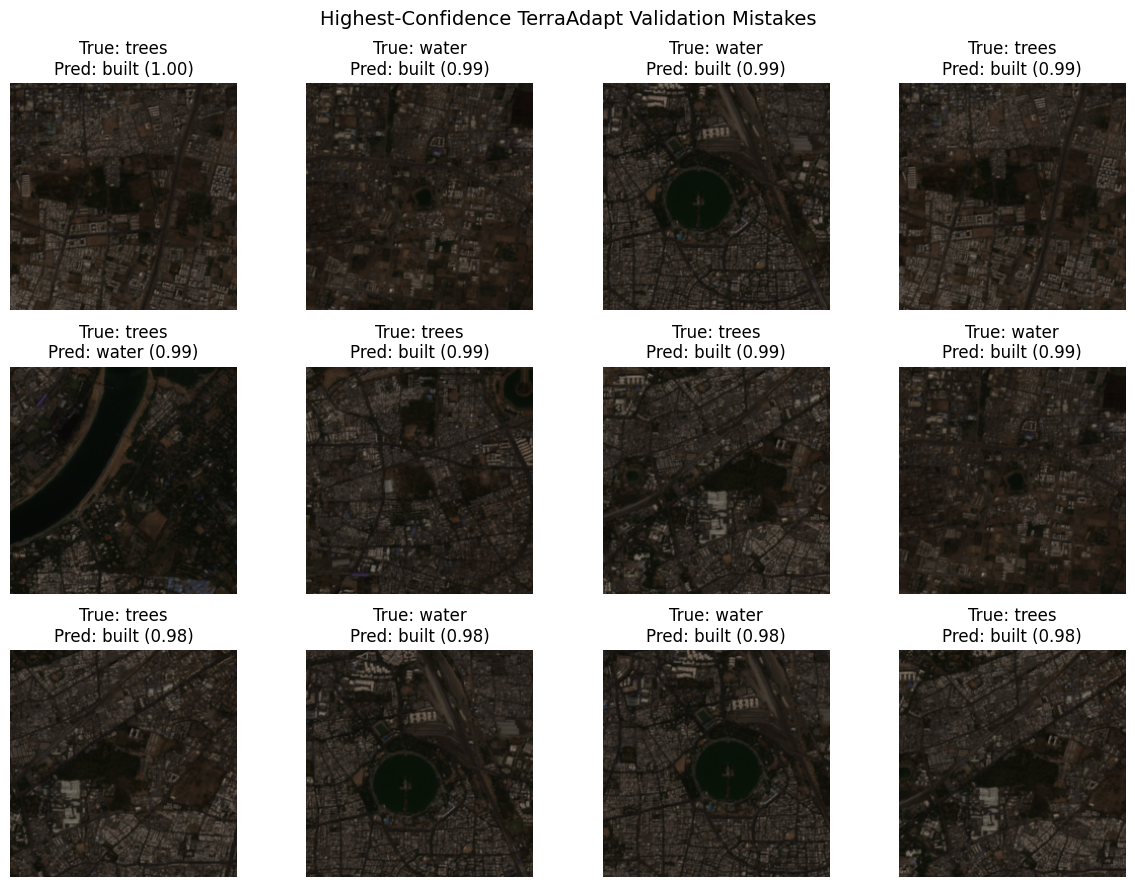

In [115]:
# Misclassified image analysis

import matplotlib.pyplot as plt
import numpy as np
import torch

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

# Collect validation images and predictions

misclassified = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images_device = images.to(device, non_blocking=True)

        outputs = model(images_device)
        probs = torch.softmax(outputs, dim=1)

        predictions = outputs.argmax(dim=1)
        confidences = probs.max(dim=1).values

        for i in range(len(labels)):
            if predictions[i].item() != labels[i].item():
                misclassified.append({
                    "image": images[i].cpu(),
                    "true": labels[i].item(),
                    "pred": predictions[i].item(),
                    "confidence": confidences[i].item()
                })

print(f"Total validation mistakes: {len(misclassified)}")

# Show the highest-confidence mistakes

misclassified.sort(
    key=lambda x: x["confidence"],
    reverse=True
)

num_images = min(12, len(misclassified))

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

axes = axes.flatten()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(num_images):
    item = misclassified[i]

    image = item["image"] * std + mean
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)

    axes[i].imshow(image)

    axes[i].set_title(
        f"True: {class_names[item['true']]}\n"
        f"Pred: {class_names[item['pred']]} "
        f"({item['confidence']:.2f})"
    )

    axes[i].axis("off")

for i in range(num_images, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Highest-Confidence TerraAdapt Validation Mistakes",
    fontsize=14
)

plt.tight_layout()
plt.show()

Most common validation mistakes:

crops  → trees : 45
water  → built : 36
trees  → built : 30
trees  → water : 12
crops  → built : 10
built  → trees : 10
water  → trees : 9
trees  → crops : 8
crops  → water : 6
built  → crops : 4
water  → crops : 2


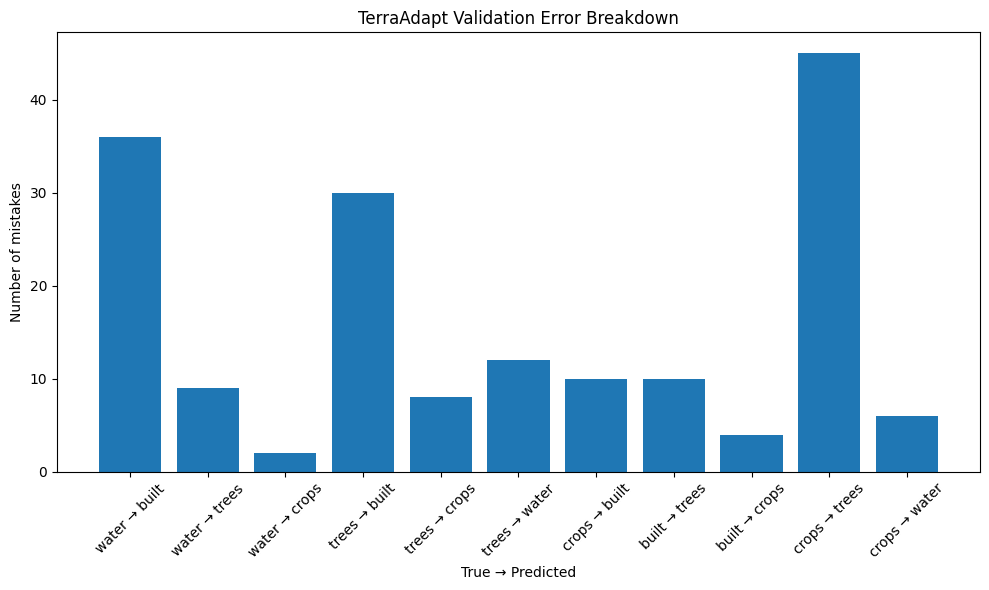

In [116]:
# Analyze the most common classification mistakes

from collections import Counter
import matplotlib.pyplot as plt

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

mistake_pairs = Counter()

for true_label, pred_label in zip(val_labels, val_preds):
    if true_label != pred_label:
        mistake_pairs[
            (class_names[true_label], class_names[pred_label])
        ] += 1

print("Most common validation mistakes:\n")

for (true_class, pred_class), count in mistake_pairs.most_common():
    print(
        f"{true_class:6s} → {pred_class:6s}: {count}"
    )

# Plot mistake pairs

labels = [
    f"{true} → {pred}"
    for (true, pred) in mistake_pairs.keys()
]

counts = list(mistake_pairs.values())

plt.figure(figsize=(10, 6))

plt.bar(labels, counts)

plt.title("TerraAdapt Validation Error Breakdown")
plt.xlabel("True → Predicted")
plt.ylabel("Number of mistakes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Confidence Statistics
Correct predictions   : 437
Incorrect predictions : 172

Mean confidence (correct):   0.7323
Mean confidence (incorrect): 0.6900

Median confidence (correct):   0.7545
Median confidence (incorrect): 0.7171


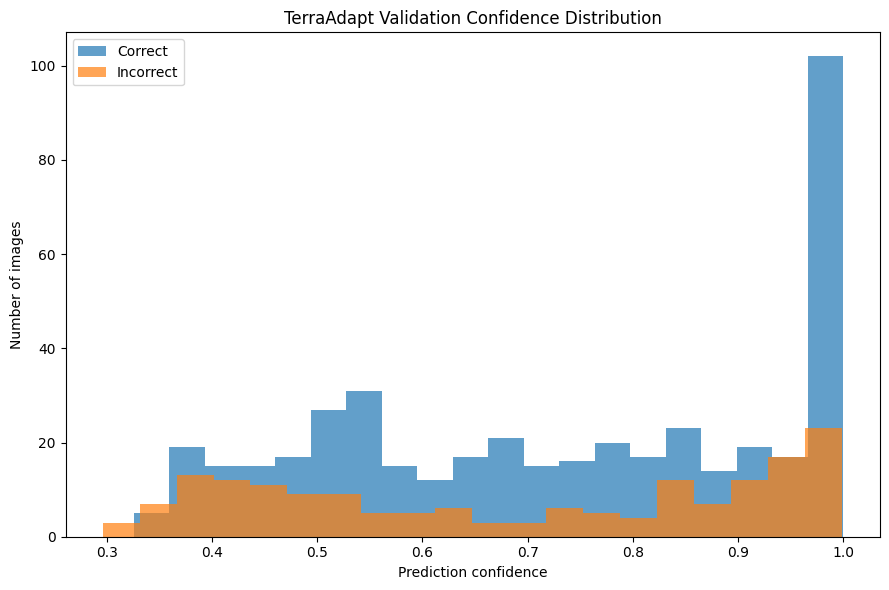

In [117]:
# Confidence analysis

import numpy as np
import matplotlib.pyplot as plt

# Maximum predicted probability for each validation image
val_confidence = val_probs.max(axis=1)

correct_mask = val_preds == val_labels
incorrect_mask = ~correct_mask

correct_confidence = val_confidence[correct_mask]
incorrect_confidence = val_confidence[incorrect_mask]

print("Confidence Statistics")
print(f"Correct predictions   : {len(correct_confidence)}")
print(f"Incorrect predictions : {len(incorrect_confidence)}")

print(
    f"\nMean confidence (correct):   "
    f"{correct_confidence.mean():.4f}"
)

print(
    f"Mean confidence (incorrect): "
    f"{incorrect_confidence.mean():.4f}"
)

print(
    f"\nMedian confidence (correct):   "
    f"{np.median(correct_confidence):.4f}"
)

print(
    f"Median confidence (incorrect): "
    f"{np.median(incorrect_confidence):.4f}"
)

# Confidence distributions

plt.figure(figsize=(9, 6))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction confidence")
plt.ylabel("Number of images")
plt.title("TerraAdapt Validation Confidence Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [118]:
# Final evaluation on the untouched test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import torch

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

# Load the best validation checkpoint

model.load_state_dict(
    torch.load(
        "/content/terraadapt_resnet50_best.pth",
        map_location=device
    )
)

model.eval()

test_preds = []
test_labels = []
test_probs = []

# Generate test predictions

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        test_preds.extend(
            outputs.argmax(dim=1).cpu().numpy()
        )

        test_labels.extend(
            labels.numpy()
        )

        test_probs.extend(
            probs.cpu().numpy()
        )

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Calculate final test metrics

test_accuracy = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds,
    average="macro"
)

test_recall = recall_score(
    test_labels,
    test_preds,
    average="macro"
)

test_f1 = f1_score(
    test_labels,
    test_preds,
    average="macro"
)

test_roc_auc_macro = roc_auc_score(
    test_labels,
    test_probs,
    multi_class="ovr",
    average="macro"
)

test_roc_auc_weighted = roc_auc_score(
    test_labels,
    test_probs,
    multi_class="ovr",
    average="weighted"
)

# Display final results

print("Final TerraAdapt Test Metrics")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro Precision:   {test_precision:.4f}")
print(f"Macro Recall:      {test_recall:.4f}")
print(f"Macro F1:          {test_f1:.4f}")
print(f"Macro ROC-AUC:     {test_roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC:  {test_roc_auc_weighted:.4f}")

print("\nTest Classification Report")

print(
    classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4
    )
)

print("\nTest Confusion Matrix")
print(
    confusion_matrix(
        test_labels,
        test_preds
    )
)

Final TerraAdapt Test Metrics
Accuracy:          0.5402
Macro Precision:   0.5402
Macro Recall:      0.5431
Macro F1:          0.5361
Macro ROC-AUC:     0.8259
Weighted ROC-AUC:  0.8252

Test Classification Report
              precision    recall  f1-score   support

       water     0.6940    0.6200    0.6549       150
       trees     0.5113    0.4533    0.4806       150
       crops     0.4118    0.3522    0.3797       159
       built     0.5437    0.7467    0.6292       150

    accuracy                         0.5402       609
   macro avg     0.5402    0.5431    0.5361       609
weighted avg     0.5383    0.5402    0.5338       609


Test Confusion Matrix
[[ 93  13  26  18]
 [ 34  68  34  14]
 [  5  36  56  62]
 [  2  16  20 112]]


Final Test Confusion Matrix:
[[ 93  13  26  18]
 [ 34  68  34  14]
 [  5  36  56  62]
 [  2  16  20 112]]


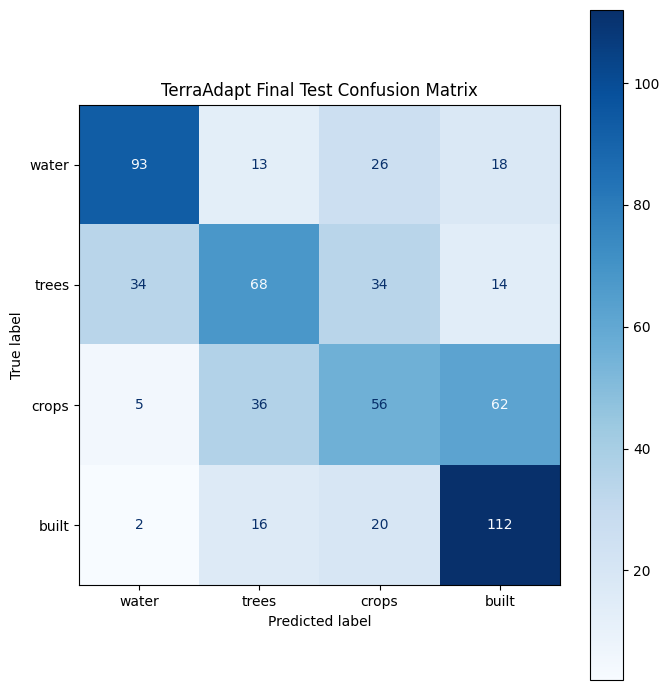

In [119]:
# Final test confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

test_cm = confusion_matrix(
    test_labels,
    test_preds
)

print("Final Test Confusion Matrix:")
print(test_cm)

fig, ax = plt.subplots(figsize=(7, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

ax.set_title("TerraAdapt Final Test Confusion Matrix")

plt.tight_layout()
plt.show()

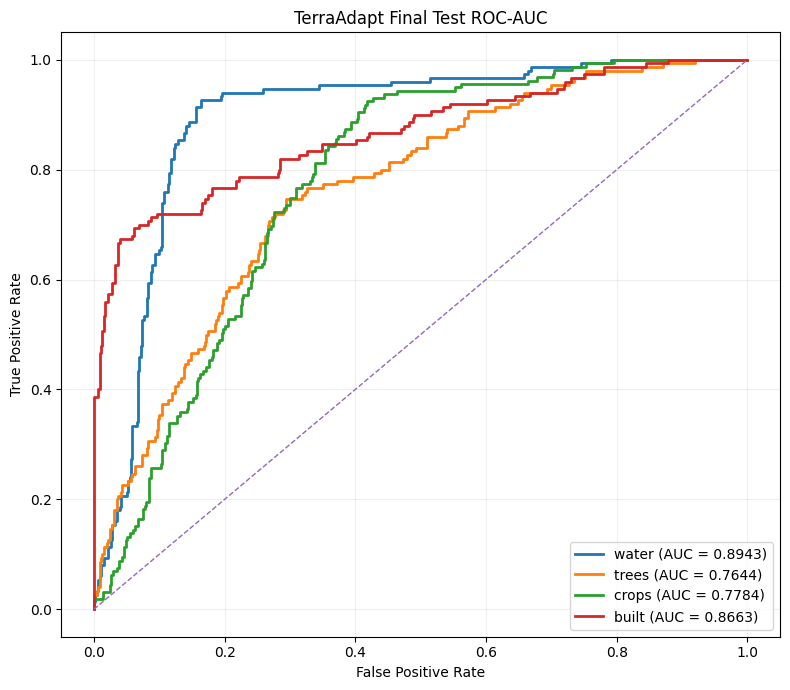

In [120]:
# Final test ROC-AUC curves

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

class_names = [
    "water",
    "trees",
    "crops",
    "built"
]

y_test_bin = label_binarize(
    test_labels,
    classes=[0, 1, 2, 3]
)

plt.figure(figsize=(8, 7))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        test_probs[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TerraAdapt Final Test ROC-AUC")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()